In [1]:
#pip install statsmodels

#### Cell 1 - Setup and load all company data:

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, spearmanr, kendalltau
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

companies = {
    "AMD": {
        "sentiment": "../data/processed/amd_scored.csv",
        "esg": "../data/raw/Advanced_Micro_Devices_esg_CLEANUP.xlsx",
    },
    "NVIDIA": {
        "sentiment": "../data/processed/nvidia_scored.csv",
        "esg": "../data/raw/Nvidia_esg_CLEANUP.xlsx",
    },
    "HP": {
        "sentiment": "../data/processed/hp_scored.csv",
        "esg": "../data/raw/HP_Inc_esg_CLEANUP.xlsx",
    },
    "DELL": {
        "sentiment": "../data/processed/dell_scored.csv",
        "esg": "../data/raw/Dell_Technologies_esg_CLEANUP.xlsx",
    },
}

# ------------------------------------------------------------
# Metriken, die ohne weitere Umrechnung in die Analyse eingehen
# ------------------------------------------------------------
# ENTFERNT ggü. alter Version:
#   "GHG Intensity"            -> wird in Patch D selbst berechnet
#   "Board Meeting Attendance" -> Extraktionsfehler, siehe EXCLUDED_METRICS
ANALYSIS_METRICS_RAW = [
    # Environment
    "Renewable Energy Percentage",
    # Social
    "Employee Turnover Rate",
    "Women in Workforce",
    "Women in Management",
    "Women in Senior Management",
    "Training Hours per Employee",
    "Total Recordable Injury Rate", 
    # Governance
    "Board Independence",
    "Women on Board",
    "CEO Pay Ratio",
    "Say-on-Pay Approval",
    "Effective Tax Rate",
]

COMPONENT_METRICS = [
    "Total Employees", "Total Revenue", "Board Size",
    "Independent Directors", "Female Directors",
    "Total Hours Worked",
]

POLICY_METRICS = [
    "Science-Based Targets / Net Zero", "Dual-Class Shares",
    "Code of Ethics", "Anti-Corruption Policy",
    "Whistleblower Policy", "Supplier Code of Conduct",
    "Country-by-Country Reporting", "Accounting Controversies",
    "Ethics Violations", "Workplace Fatalities", "Data Breaches",
]

# ------------------------------------------------------------
# Dokumentierte Ausschlüsse (fuer Kapitel 3.2.3 / 3.2.4)
# ------------------------------------------------------------
EXCLUDED_METRICS = {
    "Board Meeting Attendance":
        "Nicht messbar aus Proxy Statements. SEC Reg. S-K Item 407(b)(1) verlangt nur die "
        "Offenlegung, WENN ein Direktor unter 75 % der Sitzungen besucht. Firmen berichten "
        "daher standardmässig 'at least 75 %' als regulatorische Untergrenze, nicht als "
        "Ist-Wert. Angabe zensiert und ueber alle Firmen/Jahre konstant (Varianz null).",
    "GHG Intensity (berichtet)":
        "Definition firmenspezifisch. AMD berichtet 569-1116 tCO2e/Mio. USD, während "
        "(Scope 1 + Scope 2 market-based)/Umsatz nur 1,71-6,33 ergibt. HP und Dell berichten "
        "exakt den berechneten Wert, Nvidia weicht moderat ab. Ersetzt durch eigene Berechnung.",
    "Recordable Injuries":
        "Einheiteninkonsistenz. AMD berichtet absolute Zählungen (6-14), Nvidia, HP und Dell "
        "berichten unter diesem Namen dieselbe Rate wie unter 'Total Recordable Injury Rate'. "
        "Die Pro-Kopf-Normierung erzeugt einen Faktor 100 zwischen AMD und den uebrigen Firmen, "
        "der ausschliesslich auf der Einheitendifferenz beruht.",
    "Lost Time Injuries":
        "Einheiteninkonsistenz wie bei Recordable Injuries (AMD 'count', HP/Nvidia "
        "'per 200,000 hours'); zusätzlich fehlen Dell-Daten vollständig (n = 11).",
    "Lost Time Injury Frequency Rate":
        "Drei verschiedene Nenner ueber vier Firmen (pro 1.000.000 h / pro 200.000 h / "
        "pro 100 FTE). Nach Harmonisierung verbleibt kaum Within-Varianz: AMD in vier von "
        "fuenf Jahren exakt 0, HP ueber alle fuenf Jahre konstant 0,06. Die gepoolte "
        "Korrelation misst ueberwiegend Niveauunterschiede zwischen den Firmen.",
    "Water Recycled/Reused":
        "Datenabdeckung zu gering fuer eine Panelkorrelation (< 6 Unternehmen-Jahre).",
    "E-Waste Generated / E-Waste Recycling Rate":
        "Datenabdeckung zu gering; zusätzlich Einheitenkonflikt bei der Recycling Rate "
        "(Dell '%', HP und Nvidia 'tonnes').",
}



# LTIFR_SCALE wird nach dem Ausschluss nicht mehr benötigt, bleibt aber zu
# Dokumentationszwecken erhalten (fuer Kapitel 3.2.4).
LTIFR_SCALE = {"AMD": 1/5, "NVIDIA": 1.0, "HP": 1.0, "DELL": 1.0}


PRIMARY_SENT = "mean_roberta"
SENT_MODELS  = ["mean_roberta", "mean_vader", "mean_siebert", "mean_nlptown"]

YEAR_RANGE      = (2020, 2024)   # Analysepanel
YEAR_RANGE_LAG  = (2019, 2024)   # inkl. Vorjahresbasis fuer die Lag-Analyse

print(f"Roh-Analysemetriken: {len(ANALYSIS_METRICS_RAW)}")
print(f"Dokumentierte Ausschluesse: {len(EXCLUDED_METRICS)}")

Roh-Analysemetriken: 12
Dokumentierte Ausschluesse: 7


#### LaTeX Helper Functions:

In [3]:
# ============================================================
# LaTeX-Export-Hilfsfunktionen
# ============================================================

def df_to_latex_table(df, caption, label, filename,
                      output_dir="../results/latex/"):
    import os
    os.makedirs(output_dir, exist_ok=True)

    def escape_latex(text):
        """Escaped LaTeX-Sonderzeichen in Strings."""
        if not isinstance(text, str):
            return text
        replacements = [
            ('_', '\\_'),
            ('%', '\\%'),
            ('&', '\\&'),
            ('#', '\\#'),
            ('$', '\\$'),
        ]
        for old, new in replacements:
            text = text.replace(old, new)
        return text

    def format_val(val, col_name):
        """Formatiert Werte je nach Typ."""
        if isinstance(val, float):
            if pd.isna(val):
                return "--"
            return f"${val:+.3f}$"
        if isinstance(val, (int, np.integer)):
            return str(val)
        return escape_latex(str(val))

    lines = []
    lines.append("\\begin{table}[H]")
    lines.append("  \\centering")
    lines.append("  \\small")
    lines.append(f"  \\caption{{{caption}}}")
    lines.append(f"  \\label{{{label}}}")

    n_cols = len(df.columns)
    col_fmt = "l " + " ".join(["r"] * (n_cols - 1))
    lines.append(f"  \\begin{{tabular}}{{{col_fmt}}}")
    lines.append("    \\toprule")

    header = " & ".join(
        [f"\\textbf{{{escape_latex(str(c))}}}" for c in df.columns]
    )
    lines.append(f"    {header} \\\\")
    lines.append("    \\midrule")

    for _, row in df.iterrows():
        cells = [format_val(val, col) for val, col
                 in zip(row, df.columns)]
        lines.append(f"    {' & '.join(cells)} \\\\")

    lines.append("    \\bottomrule")
    lines.append("  \\end{tabular}")
    lines.append("\\end{table}")

    tex_code = "\n".join(lines)

    filepath = os.path.join(output_dir, filename)
    with open(filepath, "w", encoding="utf-8") as f:
        f.write(tex_code)

    print(f"LaTeX-Tabelle gespeichert: {filepath}")


def corr_to_latex(corr_df, caption, label, filename,
                  output_dir="../results/latex/"):
    import os
    os.makedirs(output_dir, exist_ok=True)

    def escape_latex(text):
        if not isinstance(text, str):
            return text
        for old, new in [('_', '\\_'), ('%', '\\%'),
                         ('&', '\\&'), ('#', '\\#')]:
            text = text.replace(old, new)
        return text

    lines = []
    lines.append("\\begin{table}[H]")
    lines.append("  \\centering")
    lines.append("  \\small")
    lines.append(f"  \\caption{{{caption}}}")
    lines.append(f"  \\label{{{label}}}")
    lines.append("  \\begin{tabular}{l l r r r r r c}")
    lines.append("    \\toprule")
    lines.append("    \\textbf{Metrik} & \\textbf{Säule} & "
                 "$n$ & $r$ & $p$ & $\\rho$ & $\\tau$ & "
                 "\\textbf{Übst.} \\\\")
    lines.append("    \\midrule")

    current_pillar = None
    for _, row in corr_df.iterrows():
        if row.get("pillar") != current_pillar and \
           current_pillar is not None:
            lines.append("    \\addlinespace")
        current_pillar = row.get("pillar")

        metric = escape_latex(str(row["metric"]))
        if len(metric) > 40:
            metric = metric[:37] + "\\dots"

        pillar = str(row.get("pillar", ""))[:3]
        n = int(row.get("n_obs", 0))
        pr = row.get("pearson_r", float("nan"))
        pp = row.get("pearson_p", float("nan"))
        sr = row.get("spearman_r", float("nan"))
        kt = row.get("kendall_tau", float("nan"))
        agree = row.get("methods_agree", "")

        if pd.isna(pp):
            sig = ""
        elif pp < 0.01:
            sig = "***"
        elif pp < 0.05:
            sig = "**"
        elif pp < 0.1:
            sig = "*"
        else:
            sig = ""

        pr_s = f"${pr:+.3f}${sig}" if not pd.isna(pr) else "--"
        pp_s = f"${pp:.4f}$" if not pd.isna(pp) else "--"
        sr_s = f"${sr:+.3f}$" if not pd.isna(sr) else "--"
        kt_s = f"${kt:+.3f}$" if not pd.isna(kt) else "--"

        lines.append(
            f"    {metric} & {pillar} & {n} & "
            f"{pr_s} & {pp_s} & {sr_s} & "
            f"{kt_s} & {agree} \\\\"
        )

    lines.append("    \\bottomrule")
    lines.append("  \\end{tabular}")
    lines.append("  \\par\\vspace{0.3cm}")
    lines.append("  {\\footnotesize\\textit{Anmerkung:} "
                 "*** $p<0{,}01$, ** $p<0{,}05$, * $p<0{,}1$. "
                 "$r$ = Pearson, $\\rho$ = Spearman, "
                 "$\\tau$ = Kendall. "
                 "Übst. = Übereinstimmung aller drei Methoden "
                 "in der Korrelationsrichtung.}")
    lines.append("\\end{table}")

    tex_code = "\n".join(lines)

    filepath = os.path.join(output_dir, filename)
    with open(filepath, "w", encoding="utf-8") as f:
        f.write(tex_code)

    print(f"LaTeX-Tabelle gespeichert: {filepath}")
    

def heatmap_to_pdf(corr_matrix, title, filename,
                   output_dir="../results/latex/"):
    """
    Exportiert eine Heatmap als hochauflösende PDF
    für \includegraphics{} in LaTeX.
    """
    import os
    os.makedirs(output_dir, exist_ok=True)

    fig, ax = plt.subplots(
        figsize=(max(6, len(corr_matrix.columns) * 2),
                 len(corr_matrix.index) * 0.45 + 2)
    )
    sns.heatmap(
        corr_matrix.astype(float),
        annot=True, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
        fmt=".2f", linewidths=0.5, ax=ax,
        cbar_kws={"label": "Pearson $r$"},
        annot_kws={"size": 9}
    )
    ax.set_title(title, fontsize=12, pad=15)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="both", labelsize=9)

    filepath = os.path.join(output_dir, filename)
    plt.tight_layout()
    plt.savefig(filepath, dpi=300, bbox_inches="tight")
    plt.savefig(filepath.replace(".pdf", ".png"),
                dpi=300, bbox_inches="tight")
    plt.close()

    print(f"Heatmap gespeichert: {filepath}")
    print(f"  (auch als PNG: {filepath.replace('.pdf', '.png')})")


def line_chart_to_pgfplots(panel_df, metric, sentiment_col,
                           company_list, pillar_map, filename,
                           output_dir="../results/latex/"):
    """
    Exportiert ein Dual-Axis-Liniendiagramm als pgfplots LaTeX-Code.
    """
    import os
    os.makedirs(output_dir, exist_ok=True)

    # Daten vorbereiten
    metric_clean = (metric.replace("_", "\\_")
                          .replace("%", "\\%")
                          .replace("&", "\\&"))

    lines = []
    lines.append("\\begin{figure}[H]")
    lines.append("  \\centering")
    lines.append("  \\begin{tikzpicture}")
    lines.append("    \\begin{axis}[")
    lines.append("      width=0.85\\textwidth,")
    lines.append("      height=6cm,")
    lines.append(f"      xlabel={{Jahr}},")
    lines.append(f"      ylabel={{{metric_clean}}},")
    lines.append("      axis y line*=left,")
    lines.append("      legend style={at={(0.5,-0.25)}, "
                 "anchor=north, legend columns=2},")
    lines.append("      xtick=data,")
    lines.append("      grid=major,")
    lines.append("      grid style={gray!20},")
    lines.append("    ]")

    colors = ["blue", "red", "green!60!black", "orange"]
    for i, company in enumerate(company_list):
        comp_data = panel_df[panel_df["company"] == company][
            ["year", metric]
        ].dropna().sort_values("year")
        if len(comp_data) == 0:
            continue
        coords = " ".join(
            [f"({int(r['year'])},{r[metric]:.4f})"
             for _, r in comp_data.iterrows()]
        )
        lines.append(f"    \\addplot[{colors[i % len(colors)]}, "
                     f"thick, mark=*] coordinates {{{coords}}};")
        lines.append(f"    \\addlegendentry{{{company} -- "
                     f"{metric_clean}}}")

    lines.append("    \\end{axis}")

    # Zweite Y-Achse für Sentiment
    lines.append("    \\begin{axis}[")
    lines.append("      width=0.85\\textwidth,")
    lines.append("      height=6cm,")
    lines.append("      ylabel={Mean RoBERTa Sentiment},")
    lines.append("      axis y line*=right,")
    lines.append("      axis x line=none,")
    lines.append("      xtick=data,")
    lines.append("      legend style={at={(0.5,-0.40)}, "
                 "anchor=north, legend columns=2},")
    lines.append("    ]")

    for i, company in enumerate(company_list):
        comp_data = panel_df[panel_df["company"] == company][
            ["year", sentiment_col]
        ].dropna().sort_values("year")
        if len(comp_data) == 0:
            continue
        coords = " ".join(
            [f"({int(r['year'])},{r[sentiment_col]:.4f})"
             for _, r in comp_data.iterrows()]
        )
        lines.append(f"    \\addplot[{colors[i % len(colors)]}, "
                     f"thick, dashed, mark=square*] "
                     f"coordinates {{{coords}}};")
        lines.append(f"    \\addlegendentry{{{company} -- "
                     f"Sentiment}}")

    lines.append("    \\end{axis}")
    lines.append("  \\end{tikzpicture}")
    lines.append(f"  \\caption{{Zeitverlauf: {metric_clean} und "
                 f"Mitarbeiterstimmung}}")
    lines.append(f"  \\label{{fig:{filename.replace('.tex', '')}}}")
    lines.append("\\end{figure}")

    tex_code = "\n".join(lines)

    filepath = os.path.join(output_dir, filename)
    with open(filepath, "w", encoding="utf-8") as f:
        f.write(tex_code)

    print(f"pgfplots-Diagramm gespeichert: {filepath}")
    return tex_code

#### Cell 2 - Build the multi-company panel:

In [ ]:
def load_company(name, paths):
    """Lädt Sentiment + ESG einer Firma und aggregiert auf Jahresebene."""
    sent_df = pd.read_csv(paths["sentiment"])
    sent_df = sent_df[sent_df["year"].between(*YEAR_RANGE)]

    agg = dict(
        n_reviews=("roberta_score", "count"),
        mean_roberta=("roberta_score", "mean"),
        median_roberta=("roberta_score", "median"),
        std_roberta=("roberta_score", "std"),
        mean_vader=("vader_score", "mean"),
        mean_siebert=("siebert_score", "mean"),
        mean_stars=("overall_stars", "mean"),
        pct_negative=("sentiment_label", lambda x: (x == "negative").mean()),
        pct_neutral=("sentiment_label", lambda x: (x == "neutral").mean()),
        pct_positive=("sentiment_label", lambda x: (x == "positive").mean()),
    )
    # NEU: nlptown mitaggregieren (Spaltenname ggf. an dein CSV anpassen)
    if "nlptown_stars" in sent_df.columns:
        agg["mean_nlptown"] = ("nlptown_stars", "mean")

    yearly_sent = sent_df.groupby("year").agg(**agg).reset_index()

    # NEU: Standardfehler des Jahresmittelwerts (fuer Fehlerbalken in den Grafiken)
    yearly_sent["se_roberta"] = (
        yearly_sent["std_roberta"] / np.sqrt(yearly_sent["n_reviews"])
    )
    yearly_sent["company"] = name

    esg_df = (pd.read_excel(paths["esg"]) if paths["esg"].endswith(".xlsx")
              else pd.read_csv(paths["esg"]))
    esg_df["value_num"] = pd.to_numeric(esg_df["value"], errors="coerce")

    esg_wide = esg_df.pivot_table(
        index="year", columns="metric_name", values="value_num", aggfunc="first"
    ).reset_index()
    esg_wide["company"] = name

    pillar_map = (esg_df.drop_duplicates("metric_name")
                        .set_index("metric_name")["pillar"].to_dict())

    # NEU: Einheiten fuer den Audit in Patch C mitnehmen
    units = esg_df[["metric_name", "year", "unit"]].copy()
    units["company"] = name

    merged = yearly_sent.merge(esg_wide, on=["year", "company"], how="inner")
    return merged, pillar_map, units


all_panels, all_units, all_pillar_maps = [], [], {}

for name, paths in companies.items():
    try:
        p, pmap, u = load_company(name, paths)
        all_panels.append(p)
        all_units.append(u)
        all_pillar_maps.update(pmap)
        print(f"{name}: {len(p)} company-years geladen")
    except Exception as e:
        print(f"{name}: FEHLGESCHLAGEN - {e}")

panel      = pd.concat(all_panels, ignore_index=True)
units_long = pd.concat(all_units,  ignore_index=True)

print(f"\nPanel: {len(panel)} Unternehmen-Jahre, "
      f"{panel['company'].nunique()} Firmen, Jahre {sorted(panel['year'].unique())}")

AMD: 5 company-years geladen
NVIDIA: 5 company-years geladen
HP: 5 company-years geladen
DELL: 5 company-years geladen

Panel: 20 Unternehmen-Jahre, 4 Firmen, Jahre [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


#### Cell 2b - Einheiten-Audit

In [ ]:
print("=" * 78)
print("EINHEITEN-AUDIT: Metriken mit uneinheitlichen Einheiten ueber Firmen hinweg")
print("=" * 78)

u = units_long.dropna(subset=["unit"])
u = u[u["unit"].astype(str).str.strip() != ""]

conflicts = []
for metric, grp in u.groupby("metric_name"):
    per_company = grp.groupby("company")["unit"].agg(
        lambda s: sorted(set(str(x).strip() for x in s))
    )
    distinct = sorted({x for lst in per_company for x in lst})
    if len(distinct) > 1:
        conflicts.append((metric, per_company.to_dict()))

if not conflicts:
    print("  Keine Einheitenkonflikte gefunden.")
for metric, per_company in conflicts:
    print(f"\n  {metric}")
    for co, units in per_company.items():
        print(f"      {co:8s} {units}")

print("\n" + "=" * 78)
print("VARIANZ-AUDIT: konstante Metriken (Korrelation nicht berechenbar)")
print("=" * 78)

num_cols = panel.select_dtypes(include=[np.number]).columns
flat = []
for metric in num_cols:
    if metric in ("year", "n_reviews"):
        continue
    for co, grp in panel.groupby("company"):
        vals = grp[metric].dropna()
        if len(vals) >= 2 and vals.nunique() == 1:
            flat.append((metric, co, vals.iloc[0], len(vals)))

if not flat:
    print("  Keine konstanten Metriken gefunden.")
else:
    print(f"{'Metrik':<40} {'Firma':<8} {'Wert':>12} {'n':>4}")
    print("-" * 68)
    for m, co, v, n in flat:
        print(f"{m:<40} {co:<8} {v:>12.4g} {n:>4}")

print("\nHinweis: Metriken, die bei ALLEN vier Firmen konstant sind, gehören in "
      "EXCLUDED_METRICS.\nMetriken, die bei EINER Firma konstant sind, liefern fuer "
      "diese Firma r = NaN und duerfen\nnicht als 'ueber alle vier Unternehmen konsistent' "
      "gezählt werden.")

EINHEITEN-AUDIT: Metriken mit uneinheitlichen Einheiten ueber Firmen hinweg

  E-Waste Recycling Rate
      DELL     ['%']
      HP       ['tonnes']
      NVIDIA   ['tonnes']

  Lost Time Injuries
      AMD      ['count']
      HP       ['per 200,000 hours']
      NVIDIA   ['per 200,000 work hours']

  Lost Time Injury Frequency Rate
      AMD      ['per 1,000,000 work hours']
      DELL     ['per 100 FTEs']
      HP       ['per 200,000 hours']
      NVIDIA   ['per 200,000 work hours']

  Recordable Injuries
      AMD      ['count']
      DELL     ['per 100 FTEs']
      HP       ['per 200,000 hours']
      NVIDIA   ['per 200,000 work hours']

  Renewable Energy Consumption
      AMD      ['GWh']
      DELL     ['GWH']
      HP       ['GWh']
      NVIDIA   ['GWh']

  Total Employees
      AMD      ['count']
      DELL     ['count', 'workers monitored in supply chain']
      HP       ['count']
      NVIDIA   ['count']

  Total Energy Consumption
      AMD      ['GWh']
      DELL     ['GW

#### Cell 3 - Normierung und Analyse-Metrikliste erstellen:

In [ ]:
# ---- 1. GHG Intensity selbst berechnen -------------------------------
S1, S2 = "Scope 1 GHG Emissions", "Scope 2 Market-Based"
if all(c in panel.columns for c in [S1, S2, "Total Revenue"]):
    panel["GHG Intensity (berechnet)"] = (
        (panel[S1] + panel[S2]) / panel["Total Revenue"]
    )
    all_pillar_maps["GHG Intensity (berechnet)"] = "Environment"

    print("GHG-INTENSITÄT: berichtet vs. berechnet (tCO2e pro Mio. USD)")
    print("-" * 72)
    for co, grp in panel.sort_values(["company", "year"]).groupby("company"):
        rep  = grp["GHG Intensity"].round(2).tolist() if "GHG Intensity" in panel.columns else []
        calc = grp["GHG Intensity (berechnet)"].round(2).tolist()
        print(f"  {co:7s} berichtet  {rep}")
        print(f"  {'':7s} berechnet  {calc}")
    print()
else:
    print("WARNUNG: Scope 1 / Scope 2 / Total Revenue fehlen - GHG Intensity nicht berechenbar\n")

# ---- 2. LTIFR harmonisieren ------------------------------------------
LT = "Lost Time Injury Frequency Rate"

if LT in panel.columns:
    if LT in EXCLUDED_METRICS:
        print(f"'{LT}' ist ausgeschlossen - keine Skalierung nötig.")
        print("  Berichtete Einheiten je Firma:")
        for co in companies:
            u = sorted(set(
                str(x).strip() for x in
                units_long[(units_long["company"] == co) &
                           (units_long["metric_name"] == LT)]["unit"].dropna()
            ))
            rng = panel[panel["company"] == co][LT].dropna()
            span = f"{rng.min():.4g}-{rng.max():.4g}" if len(rng) else "keine Daten"
            print(f"    {co:8s} {str(u):<32} Wertebereich {span}")
    elif globals().get("_LTIFR_SCALED", False):
        print(f"'{LT}' wurde bereits skaliert - uebersprungen (Idempotenz-Schutz).")
    else:
        before = panel.groupby("company")[LT].max().round(5).to_dict()
        panel[LT] = panel.apply(
            lambda r: r[LT] * LTIFR_SCALE.get(r["company"], 1.0), axis=1
        )
        after = panel.groupby("company")[LT].max().round(5).to_dict()
        _LTIFR_SCALED = True
        print("LTIFR harmonisiert auf 'pro 200.000 Arbeitsstunden'")
        print(f"  Max je Firma vorher:  {before}")
        print(f"  Max je Firma nachher: {after}")
print()
# ---- 3. Normierung ----------------------------------------------------
NORMALIZE_ONLY_EMPLOYEES = ["Total Training Hours"]

NORMALIZE_ONLY_REVENUE = [
    "Scope 1 GHG Emissions", "Scope 2 Market-Based", "Scope 2 Location-Based",
    "Scope 3 Emissions", "Total Energy Consumption", "Renewable Energy Consumption",
]
NORMALIZE_BOTH = [
    "Total Waste Generated", "Waste Recycled/Diverted",
    "Water Withdrawal", "Hazardous Waste", "Community Investment",
]

normalized_metrics = []

def _add_norm(metric, suffix, denominator):
    """Legt eine normierte Spalte an. KEIN 1e6-Faktor: Total Revenue ist bereits in Mio. USD."""
    new_col = f"{metric} ({suffix})"
    panel[new_col] = panel[metric] / panel[denominator]
    all_pillar_maps[new_col] = all_pillar_maps.get(metric, "Unknown")
    normalized_metrics.append(new_col)

for m in NORMALIZE_ONLY_EMPLOYEES:
    if m in panel.columns and "Total Employees" in panel.columns:
        _add_norm(m, "pro Mitarbeiter", "Total Employees")

for m in NORMALIZE_ONLY_REVENUE:
    if m in panel.columns and "Total Revenue" in panel.columns:
        _add_norm(m, "pro Mio. USD", "Total Revenue")

for m in NORMALIZE_BOTH:
    if m in panel.columns:
        if "Total Employees" in panel.columns:
            _add_norm(m, "pro Mitarbeiter", "Total Employees")
        if "Total Revenue" in panel.columns:
            _add_norm(m, "pro Mio. USD", "Total Revenue")

# ---- 4. Finale Metrikliste + z-Standardisierung ------------------------
ANALYSIS_METRICS = [m for m in ANALYSIS_METRICS_RAW if m in panel.columns]
if "GHG Intensity (berechnet)" in panel.columns:
    ANALYSIS_METRICS.append("GHG Intensity (berechnet)")
ANALYSIS_METRICS += [m for m in normalized_metrics if m in panel.columns]

if "GHG Intensity" in panel.columns and "GHG Intensity (berechnet)" in panel.columns:
    panel = panel.drop(columns=["GHG Intensity"])
    print("Alte Spalte 'GHG Intensity' (berichtet) aus dem Panel entfernt.")

panel_z = panel.copy()
for m in ANALYSIS_METRICS:
    vals = panel_z[m]
    if vals.notna().sum() >= 3 and vals.std(skipna=True) > 0:
        panel_z[f"{m}_z"] = (vals - vals.mean()) / vals.std()

print(f"Analyse-Metriken gesamt: {len(ANALYSIS_METRICS)}")
print(f"  bereits relativ / abgeleitet: "
      f"{len([m for m in ANALYSIS_METRICS if '(pro ' not in m])}")
print(f"  einfach normiert:  {len(NORMALIZE_ONLY_EMPLOYEES) + len(NORMALIZE_ONLY_REVENUE)}")
print(f"  doppelt normiert:  {len(NORMALIZE_BOTH)} Metriken -> "
      f"{len(NORMALIZE_BOTH)*2} Spalten")
print(f"  effektiv unabhängige Metriken: {len(ANALYSIS_METRICS) - len(NORMALIZE_BOTH)}")

print("\nDoppelt normierte Metriken - Richtungsvergleich:")
print(f"  {'Metrik':<28} {'pro MA':>9} {'pro Mio.USD':>12} {'Diff':>8}  Richtung")
print("  " + "-" * 68)
for m in NORMALIZE_BOTH:
    ce, cr = f"{m} (pro Mitarbeiter)", f"{m} (pro Mio. USD)"
    if ce in panel.columns and cr in panel.columns:
        v = panel[[PRIMARY_SENT, ce, cr]].dropna()
        if len(v) >= 4:
            re_, _ = pearsonr(v[PRIMARY_SENT], v[ce])
            rr_, _ = pearsonr(v[PRIMARY_SENT], v[cr])
            same = "stabil" if np.sign(re_) == np.sign(rr_) else "GEWECHSELT"
            print(f"  {m:<28} {re_:>+9.3f} {rr_:>+12.3f} {abs(re_-rr_):>8.3f}  {same}")

GHG-INTENSITÄT: berichtet vs. berechnet (tCO2e pro Mio. USD)
------------------------------------------------------------------------
  AMD     berichtet  [569.0, 780.0, 1116.0, 959.0, 709.0]
          berechnet  [6.33, 3.4, 2.03, 2.05, 1.71]
  DELL    berichtet  [3.17, 2.17, 1.99, 2.25, 1.8]
          berechnet  [3.17, 2.17, 1.99, 2.25, 1.8]
  HP      berichtet  [3.02, 2.51, 2.41, 2.73, 2.38]
          berechnet  [3.02, 2.51, 2.41, 2.73, 2.38]
  NVIDIA  berichtet  [6.3, 5.5, 3.1, 2.7, 0.9]
          berechnet  [4.12, 3.41, 3.07, 1.2, 0.42]

'Lost Time Injury Frequency Rate' ist ausgeschlossen - keine Skalierung nötig.
  Berichtete Einheiten je Firma:
    AMD      ['per 1,000,000 work hours']     Wertebereich 0-0.02
    NVIDIA   ['per 200,000 work hours']       Wertebereich 0-0.01
    HP       ['per 200,000 hours']            Wertebereich 0.06-0.06
    DELL     ['per 100 FTEs']                 Wertebereich 0.02-0.04

Alte Spalte 'GHG Intensity' (berichtet) aus dem Panel entfernt.
Analy

In [ ]:
# === KONTROLLZELLE ====================================
print("PANEL-INTEGRITÄT")
print("=" * 92)
print(f"{'Metrik':<44} {'n':>3} {'Firmen':>7} {'ohne Var.':>10} {'Max/Min Firma':>14}")
print("-" * 92)

warn_novar, warn_scale, warn_cov = [], [], []

for m in ANALYSIS_METRICS:
    sub = panel[["company", m]].dropna()
    if sub.empty:
        continue
    n, k = len(sub), sub["company"].nunique()

    novar = [co for co, g in sub.groupby("company")
             if len(g) >= 2 and g[m].nunique() == 1]

    means = sub.groupby("company")[m].mean().abs()
    means = means[means > 0]
    ratio = (means.max() / means.min()) if len(means) >= 2 else np.nan

    print(f"{m:<44} {n:>3} {k:>7} {len(novar):>10} "
          f"{(f'{ratio:>14.1f}' if not np.isnan(ratio) else f'{chr(45)*2:>14}')}")

    if novar:
        warn_novar.append((m, novar))
    if not np.isnan(ratio) and ratio > 50:
        warn_scale.append((m, ratio))
    if k < len(companies):
        warn_cov.append((m, k))

print("\n--- WARNUNGEN ---")
if warn_novar:
    print("\nOhne Within-Varianz bei mindestens einer Firma "
          "(dort r = NaN, nicht als 'alle vier konsistent' zählbar):")
    for m, cos in warn_novar:
        print(f"  {m:<44} {', '.join(cos)}")
if warn_scale:
    print("\nNiveauverhältnis zwischen Firmen > 50 "
          "(Verdacht auf Einheitendifferenz oder Ausreisser):")
    for m, r in warn_scale:
        print(f"  {m:<44} Faktor {r:.0f}")
if warn_cov:
    print("\nUnvollständige Firmenabdeckung:")
    for m, k in warn_cov:
        print(f"  {m:<44} nur {k} von {len(companies)} Firmen")
if not (warn_novar or warn_scale or warn_cov):
    print("  Keine Auffälligkeiten.")

print(f"\nAnalyse-Metriken: {len(ANALYSIS_METRICS)}  |  "
      f"effektiv unabhängig: {len(ANALYSIS_METRICS) - len(NORMALIZE_BOTH)}")

PANEL-INTEGRITÄT
Metrik                                         n  Firmen  ohne Var.  Max/Min Firma
--------------------------------------------------------------------------------------------
Renewable Energy Percentage                   20       4          0            1.8
Employee Turnover Rate                        15       3          0            2.3
Women in Workforce                            20       4          0            2.0
Women in Management                           19       4          0            1.9
Women in Senior Management                    14       3          0            2.7
Training Hours per Employee                   14       4          0           31.9
Total Recordable Injury Rate                  20       4          0            8.3
Board Independence                            20       4          0            1.4
Women on Board                                20       4          0            1.9
CEO Pay Ratio                                 20       4    

In [9]:
with open("../results/patch_ABCD_output.txt", "w", encoding="utf-8") as f:
    f.write(f"ANALYSIS_METRICS ({len(ANALYSIS_METRICS)}):\n")
    for m in ANALYSIS_METRICS:
        f.write(f"  {m}\n")
    f.write("\nPANEL (Metriken x Firma x Jahr):\n")
    cols = ["company", "year", "n_reviews", PRIMARY_SENT] + ANALYSIS_METRICS
    f.write(panel[[c for c in cols if c in panel.columns]].to_string(index=False))
    f.write("\n\nNaN je Metrik und Firma:\n")
    f.write(panel.groupby("company")[ANALYSIS_METRICS].apply(
        lambda g: g.isna().sum()).to_string())

In [10]:
panel.to_excel("../results/panel_nach_patchD.xlsx", index=False)

#### Cell 4 - Pooled correlations (all companies together):

In [ ]:
from statsmodels.stats.multitest import multipletests

results = []
for metric in ANALYSIS_METRICS:
    z_col = f"{metric}_z"
    if z_col not in panel_z.columns:
        continue
    valid = panel_z[[PRIMARY_SENT, z_col, "company"]].dropna()
    if len(valid) < 6:
        continue

    rp, pp = pearsonr(valid[PRIMARY_SENT], valid[z_col])
    rs, ps = spearmanr(valid[PRIMARY_SENT], valid[z_col])
    rk, pk = kendalltau(valid[PRIMARY_SENT], valid[z_col])

    results.append({
        "metric": metric,
        "pillar": all_pillar_maps.get(metric, "Unknown"),
        "n_obs": len(valid),
        "n_companies": valid["company"].nunique(),
        "pearson_r": round(rp, 3),  "pearson_p": round(pp, 4),
        "spearman_r": round(rs, 3), "spearman_p": round(ps, 4),
        "kendall_tau": round(rk, 3), "kendall_p": round(pk, 4),
        "methods_agree": "YES" if len({np.sign(rp), np.sign(rs), np.sign(rk)}) == 1 else "NO",
    })

pooled_corr = pd.DataFrame(results)

# --- Benjamini-Hochberg FDR ueber alle simultanen Tests ---
_, p_fdr, _, _ = multipletests(pooled_corr["pearson_p"], alpha=0.05, method="fdr_bh")
pooled_corr["p_fdr"] = p_fdr.round(4)

pooled_corr = pooled_corr.sort_values("pearson_r", key=abs, ascending=False)

print(f"Gepoolte Korrelationen: {len(pooled_corr)} Metriken "
      f"({len(pooled_corr) - len(NORMALIZE_BOTH)} effektiv unabhängig)")
print("=" * 118)
print(f"{'Metrik':<44} {'Säule':<12} {'n':>3} {'Pearson':>8} {'p':>8} "
      f"{'p_FDR':>8} {'Spearman':>9} {'Kendall':>8} {'Uebst.':>7}")
print("-" * 118)
for _, r in pooled_corr.iterrows():
    sig  = "*" if r["pearson_p"] < 0.05 else ("+" if r["pearson_p"] < 0.10 else " ")
    sigq = "*" if r["p_fdr"] < 0.05 else " "
    print(f"{r['metric']:<44} {r['pillar']:<12} {r['n_obs']:>3} "
          f"{r['pearson_r']:>+8.3f} {r['pearson_p']:>7.4f}{sig} "
          f"{r['p_fdr']:>7.4f}{sigq} {r['spearman_r']:>+9.3f} "
          f"{r['kendall_tau']:>+8.3f} {r['methods_agree']:>7}")

n_raw = (pooled_corr["pearson_p"] < 0.05).sum()
n_fdr = (pooled_corr["p_fdr"] < 0.05).sum()
agree = (pooled_corr["methods_agree"] == "YES").mean() * 100

print(f"\nDrei-Methoden-Uebereinstimmung: {agree:.0f}% "
      f"({(pooled_corr['methods_agree'] == 'YES').sum()}/{len(pooled_corr)})")
print(f"Signifikant unkorrigiert (p < 0,05):        {n_raw}")
print(f"Signifikant nach FDR-Korrektur (q < 0,05):  {n_fdr}")
print(f"Bei {len(pooled_corr)} Tests zufällig erwartet: "
      f"{len(pooled_corr)*0.05:.1f}")

corr_to_latex(
    pooled_corr,
    caption="Gepoolte Korrelationen zwischen Mitarbeiterstimmung und ESG-Metriken "
            "(alle Unternehmen)",
    label="tab:pooled_corr",
    filename="tab_pooled_correlations.tex",
)

Gepoolte Korrelationen: 30 Metriken (25 effektiv unabhängig)
Metrik                                       Säule          n  Pearson        p    p_FDR  Spearman  Kendall  Uebst.
----------------------------------------------------------------------------------------------------------------------
Women in Workforce                           Social        20   -0.676  0.0011*  0.0330*    -0.739   -0.567     YES
Scope 1 GHG Emissions (pro Mio. USD)         Environment   20   -0.639  0.0024*  0.0360*    -0.726   -0.547     YES
Women in Senior Management                   Social        14   -0.580  0.0296*  0.2160     -0.865   -0.732     YES
Women in Management                          Social        19   -0.566  0.0116*  0.1160     -0.572   -0.399     YES
Employee Turnover Rate                       Social        15   -0.544  0.0360*  0.2160     -0.559   -0.364     YES
Renewable Energy Percentage                  Environment   20   -0.408  0.0741+  0.3705     -0.442   -0.325     YES
Hazardou

#### Cell 5 - Per-company correlations (check if findings are consistent):

In [12]:
print("Per-company Korrelationen (nur Analyse-Metriken):")
print("=" * 75)

for metric in ANALYSIS_METRICS:
    has_data = False
    lines = []
    for company in sorted(panel["company"].unique()):
        comp_data = panel[panel["company"] == company][
            [PRIMARY_SENT, metric]
        ].dropna()
        if len(comp_data) >= 4:
            r, p = pearsonr(comp_data[PRIMARY_SENT], comp_data[metric])
            tau, _ = kendalltau(comp_data[PRIMARY_SENT], comp_data[metric])
            sig = "*" if p < 0.05 else " "
            lines.append(
                f"    {company:<10} r={r:+.3f}  τ={tau:+.3f}  "
                f"p={p:.3f}{sig}  (n={len(comp_data)})"
            )
            has_data = True

    if has_data:
        pillar = all_pillar_maps.get(metric, "?")
        print(f"\n  {metric} ({pillar}):")
        for line in lines:
            print(line)

Per-company Korrelationen (nur Analyse-Metriken):

  Renewable Energy Percentage (Environment):
    AMD        r=-0.143  τ=+0.000  p=0.818   (n=5)
    DELL       r=-0.689  τ=-0.400  p=0.198   (n=5)
    HP         r=-0.783  τ=-0.600  p=0.118   (n=5)
    NVIDIA     r=-0.939  τ=-0.600  p=0.018*  (n=5)

  Employee Turnover Rate (Social):
    AMD        r=+0.974  τ=+0.527  p=0.005*  (n=5)
    HP         r=-0.308  τ=-0.200  p=0.614   (n=5)
    NVIDIA     r=+0.768  τ=+0.600  p=0.130   (n=5)

  Women in Workforce (Social):
    AMD        r=+0.208  τ=+0.000  p=0.737   (n=5)
    DELL       r=-0.654  τ=-0.400  p=0.231   (n=5)
    HP         r=-0.418  τ=-0.400  p=0.483   (n=5)
    NVIDIA     r=-0.914  τ=-0.600  p=0.030*  (n=5)

  Women in Management (Social):
    AMD        r=-0.477  τ=-0.548  p=0.523   (n=4)
    DELL       r=-0.577  τ=-0.200  p=0.308   (n=5)
    HP         r=-0.025  τ=+0.200  p=0.968   (n=5)
    NVIDIA     r=-0.821  τ=-0.600  p=0.088   (n=5)

  Women in Senior Management (Social)

#### 5b - Pillar summary:

In [13]:
valid_corr = pooled_corr[pooled_corr["pearson_r"].notna()].copy()

print("Zusammenfassung nach ESG-Pillar (nur Analyse-Metriken):")
print("=" * 65)
for pillar in ["Environment", "Social", "Governance"]:
    subset = valid_corr[valid_corr["pillar"] == pillar]
    if len(subset) > 0:
        pos = (subset["pearson_r"] > 0).sum()
        neg = (subset["pearson_r"] < 0).sum()
        agree = (subset["methods_agree"] == "YES").sum()
        mean_r = subset["pearson_r"].mean()
        print(f"\n  {pillar} ({len(subset)} Metriken):")
        print(f"    Positiv: {pos} / Negativ: {neg}")
        print(f"    Mittlerer Pearson r: {mean_r:+.3f}")
        print(f"    Drei-Methoden-Übereinstimmung: {agree}/{len(subset)}")
        strongest = subset.iloc[
            subset["pearson_r"].abs().argmax()
        ]
        print(f"    Stärkste: {strongest['metric']} "
              f"(r={strongest['pearson_r']:+.3f})")

Zusammenfassung nach ESG-Pillar (nur Analyse-Metriken):

  Environment (16 Metriken):
    Positiv: 3 / Negativ: 13
    Mittlerer Pearson r: -0.163
    Drei-Methoden-Übereinstimmung: 14/16
    Stärkste: Scope 1 GHG Emissions (pro Mio. USD) (r=-0.639)

  Social (9 Metriken):
    Positiv: 1 / Negativ: 8
    Mittlerer Pearson r: -0.279
    Drei-Methoden-Übereinstimmung: 8/9
    Stärkste: Women in Workforce (r=-0.676)

  Governance (5 Metriken):
    Positiv: 3 / Negativ: 2
    Mittlerer Pearson r: -0.032
    Drei-Methoden-Übereinstimmung: 4/5
    Stärkste: Women on Board (r=-0.389)


#### Cell 6 - Fixed effects regression (the proper panel method):


In [ ]:
import statsmodels.api as sm

def panel_regression(panel_df, sentiment_col, metric, pillar_map, year_fe=True):
    """OLS mit Company-FE und optionalen Year-FE. Gibt Koeffizient, t, p, R2 zurueck."""
    z_col = f"{metric}_z"
    if z_col not in panel_df.columns:
        return None
    df = panel_df[["company", "year", sentiment_col, z_col]].dropna()
    if len(df) < 6:
        return None

    X = pd.concat(
        [df[[sentiment_col]], pd.get_dummies(df["company"], prefix="co", drop_first=True)]
        + ([pd.get_dummies(df["year"], prefix="yr", drop_first=True)] if year_fe else []),
        axis=1,
    ).astype(float)
    X = sm.add_constant(X)

    if len(df) <= X.shape[1]:
        return None
    try:
        fit = sm.OLS(df[z_col].astype(float), X).fit()
    except Exception:
        return None

    return {
        "Metrik": metric,
        "Säule": pillar_map.get(metric, "Unknown"),
        "n_obs": int(len(df)),
        "k_params": int(X.shape[1]),
        "df_resid": int(fit.df_resid),
        "sentiment_coef": round(fit.params[sentiment_col], 3),
        "t_stat": round(fit.tvalues[sentiment_col], 3),
        "p_value": round(fit.pvalues[sentiment_col], 4),
        "r_squared": round(fit.rsquared, 3),
        "r_squared_adj": round(fit.rsquared_adj, 3),
    }


for label, year_fe in [("GESAETTIGT (Company-FE + Year-FE)", True),
                       ("SPARSAM (nur Company-FE)", False)]:
    rows = [r for m in ANALYSIS_METRICS
            if (r := panel_regression(panel_z, PRIMARY_SENT, m, all_pillar_maps, year_fe))]
    fe = pd.DataFrame(rows).sort_values("p_value")

    print("\n" + "=" * 96)
    print(f"FIXED-EFFECTS-REGRESSION - {label}")
    print("=" * 96)
    if len(fe):
        print(f"Parameter: {fe['k_params'].iloc[0]}, "
              f"Freiheitsgrade bei n=20: {20 - fe['k_params'].iloc[0]}")
    print(f"{'Metrik':<44} {'Saeule':<12} {'n':>3} {'Koeff':>9} "
          f"{'t':>9} {'p':>8} {'R2':>7} {'R2adj':>7}")
    print("-" * 96)
    for _, r in fe.iterrows():
        sig = "*" if r["p_value"] < 0.05 else ("+" if r["p_value"] < 0.10 else " ")
        print(f"{r['Metrik']:<44} {r['Säule']:<12} {r['n_obs']:>3} "
              f"{r['sentiment_coef']:>+9.3f} {r['t_stat']:>+9.3f} "
              f"{r['p_value']:>7.4f}{sig} {r['r_squared']:>7.3f} "
              f"{r['r_squared_adj']:>7.3f}")

    if year_fe:
        fe_df = fe.copy()
        df_to_latex_table(
            fe_df,
            caption="Fixed-Effects-Regression: ESG-Metrik $\\sim$ Sentiment "
                    "+ Company FE + Year FE",
            label="tab:fixed_effects",
            filename="tab_fixed_effects.tex",
        )
    else:
        fe_sparse = fe.copy()
        df_to_latex_table(
            fe_sparse,
            caption="Fixed-Effects-Regression (sparsame Spezifikation): "
                    "ESG-Metrik $\\sim$ Sentiment + Company FE",
            label="tab:fixed_effects_sparse",
            filename="tab_fixed_effects_sparse.tex",
        )


FIXED-EFFECTS-REGRESSION - GESAETTIGT (Company-FE + Year-FE)
Parameter: 9, Freiheitsgrade bei n=20: 11
Metrik                                       Saeule         n     Koeff         t        p      R2   R2adj
------------------------------------------------------------------------------------------------
Community Investment (pro Mio. USD)          Social        18   -38.013    -2.696  0.0246*   0.627   0.295
Board Independence                           Governance    20    -7.380    -2.593  0.0250*   0.952   0.917
Effective Tax Rate                           Governance    20   +16.448    +2.394  0.0356*   0.721   0.518
Community Investment (pro Mitarbeiter)       Social        18   -24.698    -1.763  0.1117    0.632   0.304
Women in Workforce                           Social        20    -2.036    -1.718  0.1137    0.992   0.986
Women in Senior Management                   Social        14    -2.656    -1.538  0.1749    0.993   0.985
Women on Board                               Gover

#### Cell 7 - Lagged panel regression (sentiment predicts next year's ESG):

In [ ]:
# ---- Sentiment inkl. 2019 nachladen ----------------------------------
lag_rows = []
for name, paths in companies.items():
    s = pd.read_csv(paths["sentiment"])
    s = s[s["year"].between(*YEAR_RANGE_LAG)]
    g = s.groupby("year").agg(sent=("roberta_score", "mean"),
                              n=("roberta_score", "count")).reset_index()
    g["company"] = name
    lag_rows.append(g)

sent_full = pd.concat(lag_rows, ignore_index=True).sort_values(["company", "year"])
sent_full["sent_prev"] = sent_full.groupby("company")["sent"].shift(1)

panel_lag = panel_z.merge(
    sent_full[["company", "year", "sent_prev"]], on=["company", "year"], how="left"
)

print("Vorjahres-Sentiment verfuegbar fuer "
      f"{panel_lag['sent_prev'].notna().sum()} von {len(panel_lag)} Unternehmen-Jahren")
print("2019er Basiswerte:")
for _, r in sent_full[sent_full["year"] == 2019].iterrows():
    print(f"  {r['company']:8s} {r['n']:>5.0f} Reviews, mittleres Sentiment {r['sent']:+.3f}")

# ---- Lag-Korrelation -------------------------------------------------
rows = []
for metric in ANALYSIS_METRICS:
    z_col = f"{metric}_z"
    if z_col not in panel_lag.columns:
        continue
    sync = panel_lag[[PRIMARY_SENT, z_col]].dropna()
    lag  = panel_lag[["sent_prev", z_col]].dropna()
    if len(sync) < 6 or len(lag) < 6:
        continue

    r_s, p_s = pearsonr(sync[PRIMARY_SENT], sync[z_col])
    r_l, p_l = pearsonr(lag["sent_prev"],   lag[z_col])

    rows.append({
        "metric": metric, "pillar": all_pillar_maps.get(metric, "Unknown"),
        "n_sync": len(sync), "r_sync": round(r_s, 3), "p_sync": round(p_s, 4),
        "n_lag": len(lag),   "r_lag": round(r_l, 3),  "p_lag": round(p_l, 4),
        "abs_change": round(abs(r_l) - abs(r_s), 3),
    })

lag_corr = pd.DataFrame(rows).sort_values("r_sync", key=abs, ascending=False)

print("\n" + "=" * 100)
print("LAG-ANALYSE: Sentiment(t-1) vs. ESG(t)  im Vergleich zu  Sentiment(t) vs. ESG(t)")
print("=" * 100)
print(f"{'Metrik':<44} {'n_gl':>5} {'r_gleichz.':>11} {'p':>8} "
      f"{'n_lag':>6} {'r_lag':>8} {'p':>8}  Befund")
print("-" * 100)
for _, r in lag_corr.iterrows():
    if abs(r["r_lag"]) < abs(r["r_sync"]) - 0.10:
        verdict = "schwächer"
    elif abs(r["r_lag"]) > abs(r["r_sync"]) + 0.10:
        verdict = "STÄRKER"
    else:
        verdict = "ähnlich"
    s1 = "*" if r["p_sync"] < 0.05 else " "
    s2 = "*" if r["p_lag"]  < 0.05 else " "
    print(f"{r['metric']:<44} {r['n_sync']:>5} {r['r_sync']:>+11.3f}{s1}"
          f"{r['p_sync']:>7.4f} {r['n_lag']:>6} {r['r_lag']:>+8.3f}{s2}"
          f"{r['p_lag']:>7.4f}  {verdict}")

n_sig_sync = (lag_corr["p_sync"] < 0.05).sum()
n_sig_lag  = (lag_corr["p_lag"]  < 0.05).sum()
print(f"\nSignifikant gleichzeitig: {n_sig_sync} / {len(lag_corr)}")
print(f"Signifikant gelaggt:     {n_sig_lag} / {len(lag_corr)}")
print(f"Mittlere änderung von |r|: {lag_corr['abs_change'].mean():+.3f}")
print("\nACHTUNG bei der Interpretation: Wenn die Niveaukorrelationen durch monotone")
print("Zeittrends entstehen, MUSS die Lag-Korrelation ähnlich stark bleiben - Trends")
print("verschwinden nicht durch eine Verschiebung um ein Jahr. Ein Kollaps der")
print("Lag-Korrelation spricht daher eher fuer Rauschen bei kleinem n als fuer die")
print("Zeittrend-Erklärung. Beides zusammen als sich stuetzende Belege zu präsentieren,")
print("wäre ein Fehlschluss.")

lag_corr.to_csv("../results/lag_correlations.csv", index=False)

Vorjahres-Sentiment verfuegbar fuer 20 von 20 Unternehmen-Jahren
2019er Basiswerte:
  AMD        135 Reviews, mittleres Sentiment +0.589
  DELL      1874 Reviews, mittleres Sentiment +0.592
  HP         767 Reviews, mittleres Sentiment +0.577
  NVIDIA     197 Reviews, mittleres Sentiment +0.745

LAG-ANALYSE: Sentiment(t-1) vs. ESG(t)  im Vergleich zu  Sentiment(t) vs. ESG(t)
Metrik                                        n_gl  r_gleichz.        p  n_lag    r_lag        p  Befund
----------------------------------------------------------------------------------------------------
Women in Workforce                              20      -0.676* 0.0011     20   -0.687* 0.0008  ähnlich
Scope 1 GHG Emissions (pro Mio. USD)            20      -0.639* 0.0024     20   -0.786* 0.0000  STÄRKER
Women in Senior Management                      14      -0.580* 0.0296     14   -0.544* 0.0441  ähnlich
Women in Management                             19      -0.566* 0.0116     19   -0.511* 0.0254  ähnlich


#### Cell 8 - Multi-company heatmap:

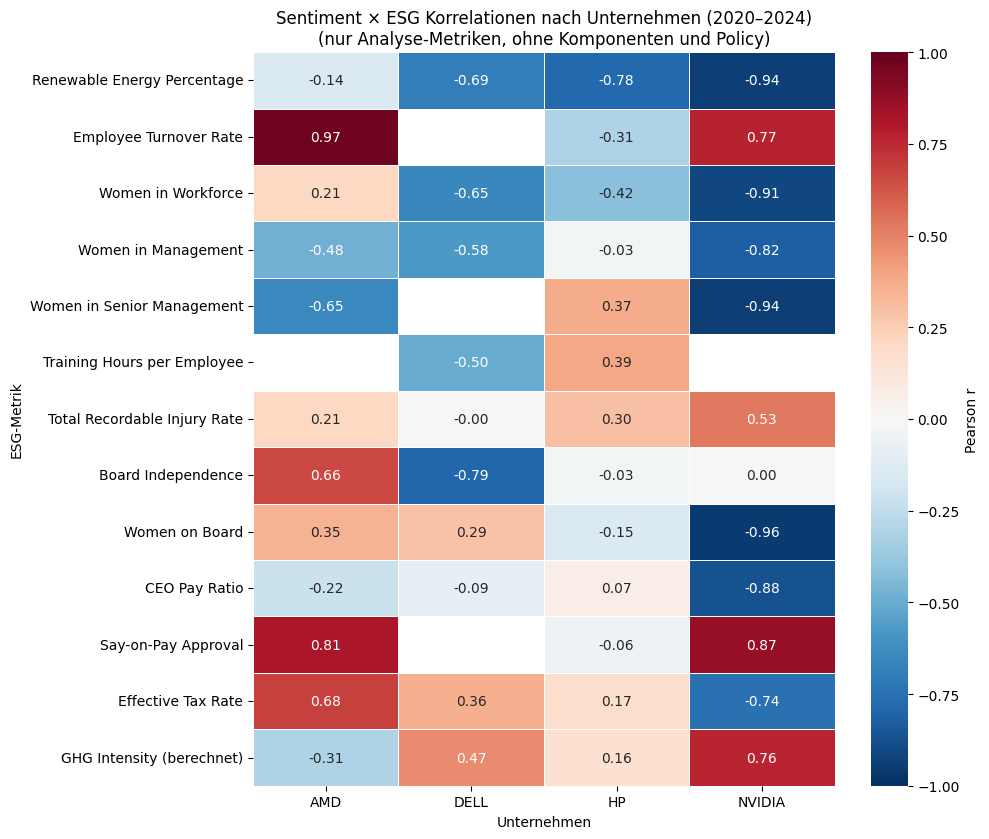

Heatmap gespeichert: ../results/latex/fig_heatmap_percompany.pdf
  (auch als PNG: ../results/latex/fig_heatmap_percompany.png)


In [16]:
# Heatmap nur mit Analyse-Metriken
heatmap_metrics = [m for m in ANALYSIS_METRICS
                   if m in panel.columns
                   and not m.endswith("(pro Mitarbeiter)")
                   and not m.endswith("(pro Mio. USD)")]

company_list = sorted(panel["company"].unique())

corr_matrix = pd.DataFrame(index=heatmap_metrics, columns=company_list)

for metric in heatmap_metrics:
    for company in company_list:
        comp_data = panel[panel["company"] == company][
            [PRIMARY_SENT, metric]
        ].dropna()
        if len(comp_data) >= 4:
            r, _ = pearsonr(comp_data[PRIMARY_SENT], comp_data[metric])
            corr_matrix.loc[metric, company] = round(r, 3)

corr_matrix = corr_matrix.astype(float)

fig, ax = plt.subplots(
    figsize=(max(8, len(company_list) * 2.5), len(heatmap_metrics) * 0.5 + 2)
)
sns.heatmap(
    corr_matrix, annot=True, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    fmt=".2f", linewidths=0.5, ax=ax, cbar_kws={"label": "Pearson r"}
)
ax.set_title(
    f"Sentiment × ESG Korrelationen nach Unternehmen "
    f"({YEAR_RANGE[0]}–{YEAR_RANGE[1]})\n"
    f"(nur Analyse-Metriken, ohne Komponenten und Policy)",
    fontsize=12
)
ax.set_xlabel("Unternehmen")
ax.set_ylabel("ESG-Metrik")

plt.tight_layout()
plt.savefig("../results/multicompany_heatmap_filtered.png",
            dpi=150, bbox_inches="tight")
plt.show()


# PDF-Export für LaTeX
heatmap_to_pdf(
    corr_matrix,
    title="Sentiment × ESG-Korrelationen nach Unternehmen",
    filename="fig_heatmap_percompany.pdf"
)

#### Cell 9 - Cross-company consistency check:

In [ ]:
MIN_N_PER_COMPANY = 4

rows = []
for metric in ANALYSIS_METRICS:
    signs, per_co = {}, {}
    for co, grp in panel.groupby("company"):
        v = grp[[PRIMARY_SENT, metric]].dropna()
        if len(v) < MIN_N_PER_COMPANY or v[metric].nunique() < 2:
            signs[co], per_co[co] = "?", np.nan
            continue
        r, _ = pearsonr(v[PRIMARY_SENT], v[metric])
        signs[co] = "+" if r > 0 else "-"
        per_co[co] = round(r, 3)

    valid = [s for s in signs.values() if s != "?"]
    rows.append({
        "metric": metric,
        "pillar": all_pillar_maps.get(metric, "Unknown"),
        **{f"sign_{c}": signs.get(c, "?") for c in companies},
        **{f"r_{c}": per_co.get(c, np.nan) for c in companies},
        "n_companies": len(valid),
        "strict": len(valid) == len(companies) and len(set(valid)) == 1,
        "loose":  len(valid) >= 3 and len(set(valid)) == 1,
        "direction": ("positiv" if valid and valid[0] == "+" else
                      "negativ" if valid else "-"),
    })

consistency = pd.DataFrame(rows)

print("UNTERNEHMENSUEBERGREIFENDE KONSISTENZ")
print(f"(mindestens {MIN_N_PER_COMPANY} Datenpunkte je Firma und Varianz > 0)")
print("=" * 96)
print(f"{'Metrik':<44} {'AMD':>5} {'DELL':>6} {'HP':>5} {'NVIDIA':>7} "
      f"{'Firmen':>7} {'streng':>8} {'weich':>7}")
print("-" * 96)
for _, r in consistency.iterrows():
    print(f"{r['metric']:<44} {r['sign_AMD']:>5} {r['sign_DELL']:>6} "
          f"{r['sign_HP']:>5} {r['sign_NVIDIA']:>7} {r['n_companies']:>7} "
          f"{('JA' if r['strict'] else '-'):>8} {('JA' if r['loose'] else '-'):>7}")

n_strict, n_loose, n_tot = (consistency["strict"].sum(),
                            consistency["loose"].sum(), len(consistency))
print(f"\nKonsistent bei ALLEN VIER Firmen: {n_strict}/{n_tot} "
      f"({n_strict/n_tot*100:.0f}%)")
print(f"Konsistent bei allen verfuegbaren (>=3 Firmen): {n_loose}/{n_tot} "
      f"({n_loose/n_tot*100:.0f}%)")
print("\nMetriken mit unvollständiger Firmenabdeckung "
      "(duerfen NICHT als 'alle vier' gelten):")
for _, r in consistency[consistency["n_companies"] < len(companies)].iterrows():
    missing = [c for c in companies if r[f"sign_{c}"] == "?"]
    print(f"  {r['metric']:<44} fehlt bei: {', '.join(missing)}")

consistency.to_csv("../results/consistency_check.csv", index=False)

UNTERNEHMENSUEBERGREIFENDE KONSISTENZ
(mindestens 4 Datenpunkte je Firma und Varianz > 0)
Metrik                                         AMD   DELL    HP  NVIDIA  Firmen   streng   weich
------------------------------------------------------------------------------------------------
Renewable Energy Percentage                      -      -     -       -       4       JA      JA
Employee Turnover Rate                           +      ?     -       +       3        -       -
Women in Workforce                               +      -     -       -       4        -       -
Women in Management                              -      -     -       -       4       JA      JA
Women in Senior Management                       -      ?     +       -       3        -       -
Training Hours per Employee                      ?      -     +       ?       2        -       -
Total Recordable Injury Rate                     +      -     +       +       4        -       -
Board Independence                   

#### Cell 10 - Summary statistics and save:

In [ ]:
print("MULTI-COMPANY ANALYSIS SUMMARY")
print("=" * 60)
print(f"Unternehmen:        {', '.join(company_list)}")
print(f"Jahre:              {YEAR_RANGE[0]}-{YEAR_RANGE[1]}")
print(f"Unternehmen-Jahre:  {len(panel)}")
print(f"Analysevariablen:   {len(ANALYSIS_METRICS)}")
print(f"davon unabhängig:  {len(ANALYSIS_METRICS) - len(NORMALIZE_BOTH)}")
print(f"Ausgeschlossen:     {len(EXCLUDED_METRICS)} (dokumentiert in EXCLUDED_METRICS)")

if "pooled_corr" in globals():
    print(f"\nGepoolte Korrelationen:")
    print(f"  signifikant p<0,05:  {(pooled_corr['pearson_p'] < 0.05).sum()}")
    if "p_fdr" in pooled_corr.columns:
        print(f"  signifikant q<0,05:  {(pooled_corr['p_fdr'] < 0.05).sum()}")
    print(f"  Drei-Methoden-Uebereinstimmung: "
          f"{(pooled_corr['methods_agree'] == 'YES').mean()*100:.0f}%")

for name, df in [("fe_df", globals().get("fe_df")),
                 ("fe_sparse", globals().get("fe_sparse"))]:
    if df is not None and len(df):
        print(f"\n{name}: signifikant p<0,05: {(df['p_value'] < 0.05).sum()}")

# --- Export ---
import os
os.makedirs("../results", exist_ok=True)

exports = {
    "multicompany_panel.csv": panel,
    "multicompany_pooled_correlations.csv": globals().get("pooled_corr"),
    "multicompany_fixed_effects.csv": globals().get("fe_df"),
    "multicompany_fixed_effects_sparse.csv": globals().get("fe_sparse"),
    "multicompany_lag_correlations.csv": globals().get("lag_corr"),
    "multicompany_heatmap_data.csv": globals().get("corr_matrix"),
    "consistency_check.csv": globals().get("consistency"),
    "within_firm_correlations.csv": globals().get("within"),
}
for fname, obj in exports.items():
    if obj is not None:
        obj.to_csv(f"../results/{fname}",
                   index=(fname == "multicompany_heatmap_data.csv"))
        print(f"  gespeichert: {fname}")

# Dokumentation der Metrikauswahl inkl. Ausschluessen
selection_doc = pd.DataFrame(
    [{"metric": m, "pillar": all_pillar_maps.get(m, "Unknown"),
      "status": "normiert" if "(pro " in m else "bereits relativ / abgeleitet",
      "begruendung": ""} for m in ANALYSIS_METRICS]
    + [{"metric": m, "pillar": all_pillar_maps.get(m, "-"),
        "status": "ausgeschlossen", "begruendung": grund}
       for m, grund in EXCLUDED_METRICS.items()]
)
selection_doc.to_csv("../results/analysis_metrics_selection.csv", index=False)
print(f"  gespeichert: analysis_metrics_selection.csv "
      f"({len(ANALYSIS_METRICS)} analysiert, {len(EXCLUDED_METRICS)} ausgeschlossen)")

MULTI-COMPANY ANALYSIS SUMMARY
Unternehmen:        AMD, DELL, HP, NVIDIA
Jahre:              2020-2024
Unternehmen-Jahre:  20
Analysevariablen:   30
davon unabhängig:  25
Ausgeschlossen:     7 (dokumentiert in EXCLUDED_METRICS)

Gepoolte Korrelationen:
  signifikant p<0,05:  5
  signifikant q<0,05:  2
  Drei-Methoden-Uebereinstimmung: 87%

fe_df: signifikant p<0,05: 3

fe_sparse: signifikant p<0,05: 3
  gespeichert: multicompany_panel.csv
  gespeichert: multicompany_pooled_correlations.csv
  gespeichert: multicompany_fixed_effects.csv
  gespeichert: multicompany_fixed_effects_sparse.csv
  gespeichert: multicompany_lag_correlations.csv
  gespeichert: multicompany_heatmap_data.csv
  gespeichert: consistency_check.csv
  gespeichert: analysis_metrics_selection.csv (30 analysiert, 7 ausgeschlossen)


#### Cell 11 — Standardizition of absolute Metrics:

In [ ]:
print("NORMIERUNGSPRUEFUNG (Normierung erfolgt in Cell 3b)")
print("=" * 78)
print(f"Normierte Spalten im Panel: {len(normalized_metrics)}")
for m in normalized_metrics:
    n = panel[m].notna().sum()
    span = f"{panel[m].min():.4g} bis {panel[m].max():.4g}"
    print(f"  {m:<46} n={n:>3}  {span}")

verdaechtig = [m for m in normalized_metrics
               if any(x in m for x in EXCLUDED_METRICS)]
if verdaechtig:
    print("\nWARNUNG: normierte Spalten ausgeschlossener Metriken gefunden:")
    for m in verdaechtig:
        print(f"  {m}")
    print("  -> NORMALIZE_ONLY_EMPLOYEES / _REVENUE / _BOTH in Cell 3b pruefen.")
else:
    print("\nKeine ausgeschlossenen Metriken unter den normierten Spalten.")

# Plausibilitätspruefung der Größenordnung
ref = "Scope 1 GHG Emissions (pro Mio. USD)"
if ref in panel.columns:
    mx = panel[ref].max()
    print(f"\n{ref}: Maximum {mx:.4g}")
    if mx > 1000:
        print("  WARNUNG: Größenordnung deutet auf einen 1e6-Faktor hin.")
    else:
        print("  Größenordnung plausibel (tCO2e je Mio. USD Umsatz).")

NORMIERUNGSPRUEFUNG (Normierung erfolgt in Cell 3b)
Normierte Spalten im Panel: 17
  Total Training Hours (pro Mitarbeiter)         n= 12  0.4189 bis 31.54
  Scope 1 GHG Emissions (pro Mio. USD)           n= 20  0.1 bis 0.9699
  Scope 2 Market-Based (pro Mio. USD)            n= 20  0.3108 bis 5.669
  Scope 2 Location-Based (pro Mio. USD)          n= 20  1.365 bis 7.016
  Scope 3 Emissions (pro Mio. USD)               n= 20  24.94 bis 1119
  Total Energy Consumption (pro Mio. USD)        n= 20  0.00469 bis 0.01576
  Renewable Energy Consumption (pro Mio. USD)    n= 20  0.001704 bis 0.02428
  Total Waste Generated (pro Mitarbeiter)        n= 19  0.02935 bis 0.5566
  Total Waste Generated (pro Mio. USD)           n= 19  0.01797 bis 0.5674
  Waste Recycled/Diverted (pro Mitarbeiter)      n= 19  0.02341 bis 0.3744
  Waste Recycled/Diverted (pro Mio. USD)         n= 19  0.01271 bis 0.3816
  Water Withdrawal (pro Mitarbeiter)             n= 20  0.004838 bis 0.05012
  Water Withdrawal (pro Mio

#### Cell 12 - Correlation of standardized metrics:

In [ ]:
from scipy.stats import kendalltau

norm_cols = [m for m in normalized_metrics if m in ANALYSIS_METRICS]
norm_results = []

for metric in norm_cols:
    valid = panel[[PRIMARY_SENT, metric, "company"]].dropna()
    if len(valid) < 6:
        continue
    r_p, p_p = pearsonr(valid[PRIMARY_SENT], valid[metric])
    r_s, _ = spearmanr(valid[PRIMARY_SENT], valid[metric])
    r_k, _ = kendalltau(valid[PRIMARY_SENT], valid[metric])
    norm_results.append({
        "metric": metric,
        "pillar": all_pillar_maps.get(metric, "Unknown"),
        "n_obs": len(valid),
        "n_companies": valid["company"].nunique(),
        "pearson_r": round(r_p, 3), "pearson_p": round(p_p, 4),
        "spearman_r": round(r_s, 3), "kendall_tau": round(r_k, 3),
        "methods_agree": "YES" if len({np.sign(r_p), np.sign(r_s),
                                       np.sign(r_k)}) == 1 else "NO",
    })

norm_corr = pd.DataFrame(norm_results).sort_values(
    "pearson_r", key=abs, ascending=False)

print(f"Korrelationen mit NORMIERTEN Metriken ({len(norm_corr)} Spalten)")
print("=" * 105)
print(f"{'Metrik':<44} {'Säule':<14} {'n':>3} {'Pearson':>8} "
      f"{'p':>8} {'Spearman':>9} {'Kendall':>8} {'Uebst.':>7}")
print("-" * 105)
for _, r in norm_corr.iterrows():
    sig = "*" if r["pearson_p"] < 0.05 else ("+" if r["pearson_p"] < 0.10 else " ")
    print(f"{r['metric']:<44} {r['pillar']:<14} {r['n_obs']:>3} "
          f"{r['pearson_r']:>+8.3f} {r['pearson_p']:>7.4f}{sig} "
          f"{r['spearman_r']:>+9.3f} {r['kendall_tau']:>+8.3f} "
          f"{r['methods_agree']:>7}")

Korrelationen mit NORMIERTEN Metriken (17 Spalten)
Metrik                                       Säule            n  Pearson        p  Spearman  Kendall  Uebst.
---------------------------------------------------------------------------------------------------------
Scope 1 GHG Emissions (pro Mio. USD)         Environment     20   -0.639  0.0024*    -0.726   -0.547     YES
Hazardous Waste (pro Mio. USD)               Environment     12   -0.389  0.2113     -0.669   -0.473     YES
Hazardous Waste (pro Mitarbeiter)            Environment     12   -0.365  0.2433     -0.501   -0.351     YES
Scope 3 Emissions (pro Mio. USD)             Environment     20   -0.358  0.1211     -0.517   -0.358     YES
Water Withdrawal (pro Mio. USD)              Environment     20   -0.252  0.2833     -0.362   -0.263     YES
Community Investment (pro Mitarbeiter)       Social          18   +0.247  0.3221     +0.030   +0.007     YES
Scope 2 Market-Based (pro Mio. USD)          Environment     20   +0.241  0.3061

#### Cell 13 - Comparison: Standardized vs. non-standardized

In [21]:
# Vergleichstabelle: Hat die Normierung die Korrelationen verändert?
print("VERGLEICH: Unnormiert vs. Normiert")
print("=" * 95)
print(f"{'Metrik':<30} {'Unnorm. r':>10} {'Norm. r':>10} {'Differenz':>10} {'Richtung':>10}")
print("-" * 95)

comparison_pairs = []

COMPARE = [m for m in (NORMALIZE_ONLY_EMPLOYEES
                       + NORMALIZE_ONLY_REVENUE
                       + NORMALIZE_BOTH)
           if m in panel.columns and m not in EXCLUDED_METRICS]

for metric in COMPARE:
    suffix = ("pro Mitarbeiter" if metric in NORMALIZE_ONLY_EMPLOYEES
              else "pro Mio. USD")
    norm_col = f"{metric} ({suffix})"          # <- muss hier drin stehen
    if norm_col not in panel.columns:
        continue
    v = panel[[PRIMARY_SENT, metric, norm_col]].dropna()
    if len(v) < 6:
        continue
    r_un, _ = pearsonr(v[PRIMARY_SENT], v[metric])
    r_no, _ = pearsonr(v[PRIMARY_SENT], v[norm_col])
    diff = r_no - r_un

    # Hat sich die Richtung geändert?
    if (r_un > 0) == (r_no > 0):
        direction = "stabil"
    else:
        direction = "GEWECHSELT"

    comparison_pairs.append({
        "metric": metric,
        "r_raw": r_un,
        "r_norm": r_no,
        "diff": diff,
        "direction": direction
    })

    print(
        f"{metric:<30} {r_un:>+10.3f} {r_no:>+10.3f} "
        f"{diff:>+10.3f} {direction:>10}"
    )

# Zusammenfassung
stable = sum(1 for p in comparison_pairs if p["direction"] == "stabil")
switched = sum(1 for p in comparison_pairs if p["direction"] == "GEWECHSELT")
print(f"\nRichtung stabil: {stable}/{len(comparison_pairs)}")
print(f"Richtung gewechselt: {switched}/{len(comparison_pairs)}")

if switched > 0:
    print("\nACHTUNG: Folgende Metriken wechseln die Korrelationsrichtung")
    print("nach Normierung — die unnormierten Ergebnisse sind hier")
    print("möglicherweise durch Größenunterschiede verzerrt:")
    for p in comparison_pairs:
        if p["direction"] == "GEWECHSELT":
            print(f"  {p['metric']}: {p['r_raw']:+.3f} → {p['r_norm']:+.3f}")

VERGLEICH: Unnormiert vs. Normiert
Metrik                          Unnorm. r    Norm. r  Differenz   Richtung
-----------------------------------------------------------------------------------------------
Total Training Hours               -0.208     -0.033     +0.175     stabil
Scope 1 GHG Emissions              -0.529     -0.639     -0.110     stabil
Scope 2 Market-Based               -0.180     +0.241     +0.421 GEWECHSELT
Scope 2 Location-Based             -0.345     -0.014     +0.330     stabil
Scope 3 Emissions                  -0.514     -0.358     +0.156     stabil
Total Energy Consumption           -0.331     +0.121     +0.452 GEWECHSELT
Renewable Energy Consumption       -0.341     -0.214     +0.127     stabil
Total Waste Generated              -0.358     -0.148     +0.210     stabil
Waste Recycled/Diverted            -0.408     -0.159     +0.249     stabil
Water Withdrawal                   -0.421     -0.252     +0.168     stabil
Hazardous Waste                    -0.367   

#### Cell 14 - Heatmap - Standardized vs. non-standardized

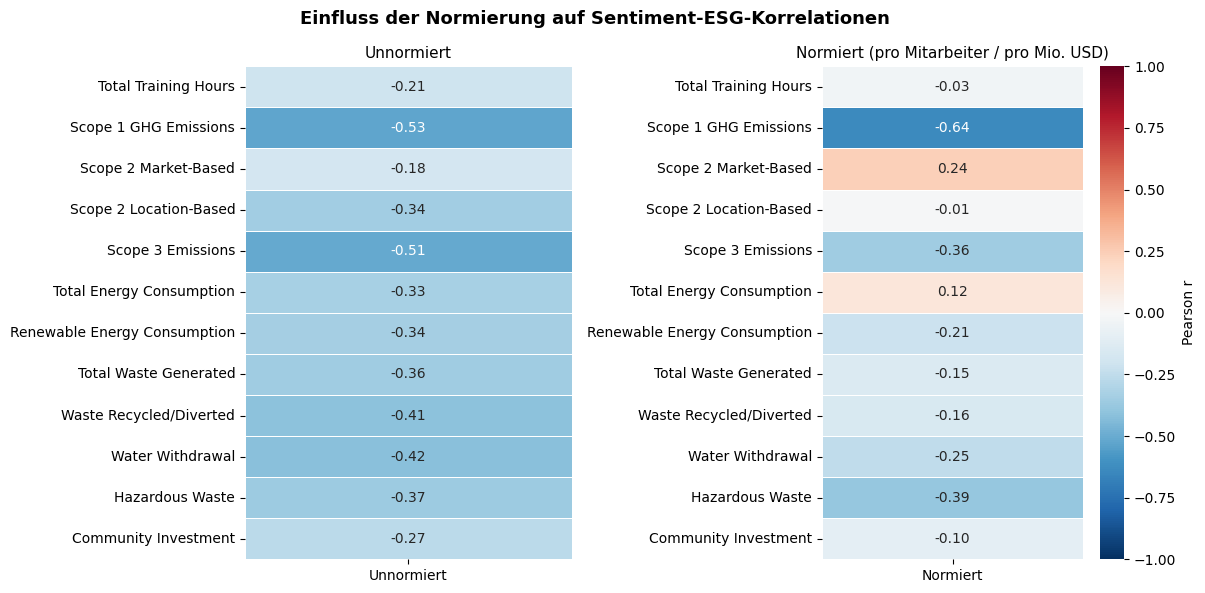

In [22]:
# Visuelle Gegenüberstellung
metrics_to_compare = [p["metric"] for p in comparison_pairs]

fig, axes = plt.subplots(1, 2, figsize=(12, max(6, len(metrics_to_compare) * 0.5)))

# Links: unnormiert
raw_vals = pd.DataFrame(
    {"Unnormiert": [p["r_raw"] for p in comparison_pairs]},
    index=[p["metric"] for p in comparison_pairs]
)
sns.heatmap(
    raw_vals, annot=True, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    fmt=".2f", linewidths=0.5, ax=axes[0], cbar=False
)
axes[0].set_title("Unnormiert", fontsize=11)

# Rechts: normiert
norm_vals = pd.DataFrame(
    {"Normiert": [p["r_norm"] for p in comparison_pairs]},
    index=[p["metric"] for p in comparison_pairs]
)
sns.heatmap(
    norm_vals, annot=True, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    fmt=".2f", linewidths=0.5, ax=axes[1], cbar_kws={"label": "Pearson r"}
)
axes[1].set_title("Normiert (pro Mitarbeiter / pro Mio. USD)", fontsize=11)

plt.suptitle(
    "Einfluss der Normierung auf Sentiment-ESG-Korrelationen",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig("../results/normierung_vergleich.png", dpi=150, bbox_inches="tight")
plt.show()

#### Cell 15 - Save Results

In [23]:
norm_corr.to_csv(
    "../results/multicompany_normalized_correlations.csv", index=False
)

comp_df_out = pd.DataFrame(comparison_pairs)
comp_df_out.to_csv(
    "../results/normierung_vergleich.csv", index=False
)

print("Gespeichert:")
print("  - multicompany_normalized_correlations.csv")
print("  - normierung_vergleich.csv")

Gespeichert:
  - multicompany_normalized_correlations.csv
  - normierung_vergleich.csv


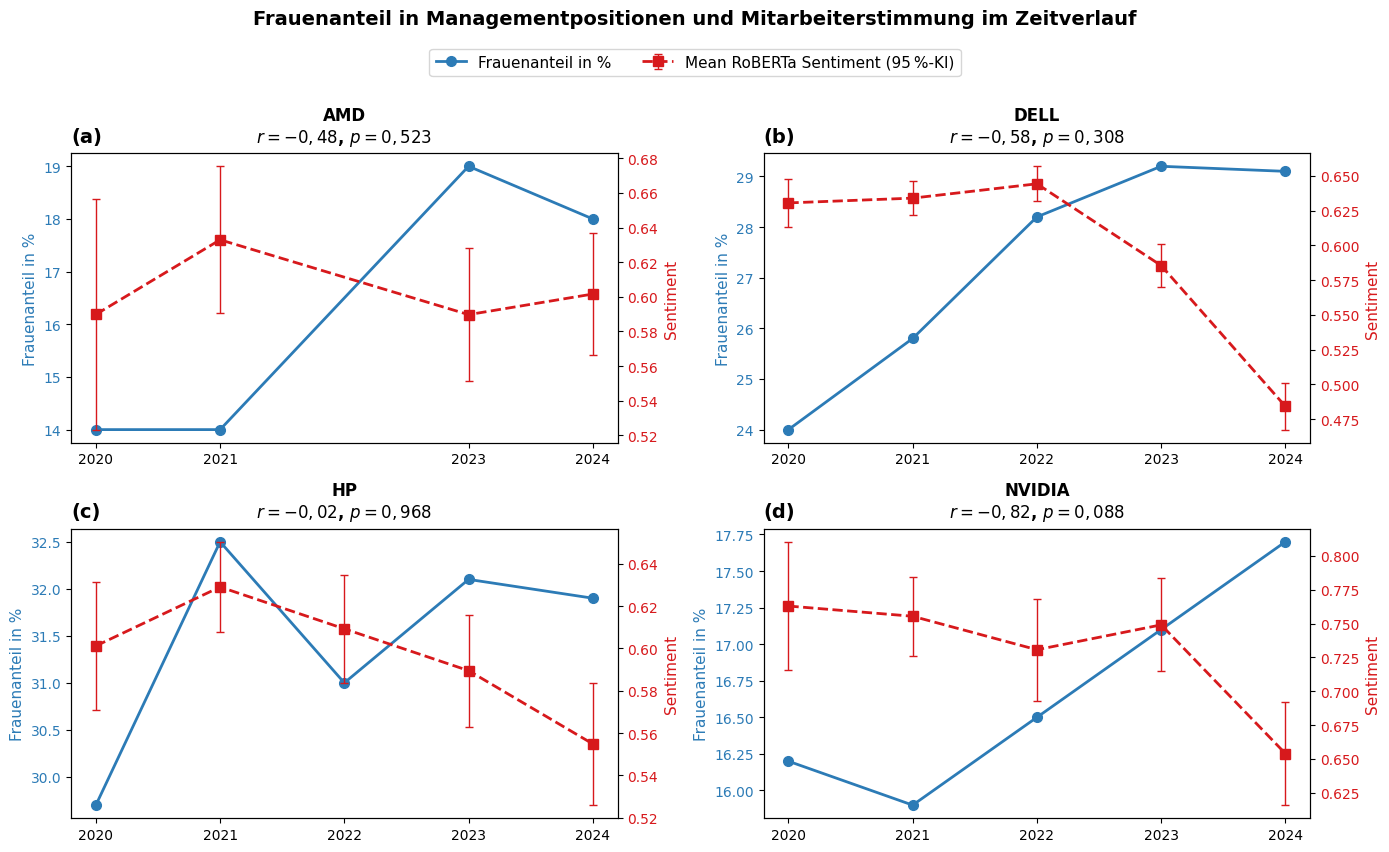

Geplottete Spalte: 'Women in Management'
          min   max
company            
AMD      14.0  19.0
DELL     24.0  29.2
HP       29.7  32.5
NVIDIA   15.9  17.7


In [72]:

# =============================================================================
import math
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
 
# --- Was geplottet werden soll -------------
PLOT_CONFIGS = {
    "women_in_management": dict(
        metric="Women in Management",
        label="Frauenanteil in Managementpositionen",
        unit="Frauenanteil in %",
        filename="fig_women_in_management",
        ymax=None,
    ),
    "say_on_pay": dict(
        metric="Say-on-Pay Approval",
        label="Say-on-Pay Zustimmung",
        unit="Say-on-Pay Zustimmung in %",
        filename="fig_say_on_pay_approval",
        ymax=100,
    ),
    "ghg_intensity": dict(
        metric="GHG Intensity (berechnet)",    
        label="GHG-Intensität",
        unit=r"tCO$_2$e pro Mio. USD",            # kein "$USD" mehr
        filename="fig_ghg_intensity",
        ymax=None,
    ),
    "renewable_share": dict(
        metric="Renewable Energy Percentage",
        label="Anteil erneuerbarer Energien",
        unit="Anteil erneuerbarer Energien in %",
        filename="fig_renewable_energy_percentage",
        ymax=100,
    ),
    "board_independence": dict(
        metric="Board Independence",
        label="Board-Unabhängigkeit",
        unit="Board-Unabhängigkeit in %",
        filename="fig_board_independence",
        ymax=100,
    ),
}
 
PLOT = "women_in_management"        # <<< hier umschalten
SHOW_ERRORBARS = True         # Standardfehler des Sentiment-Jahresmittels
 
# -----------------------------------------------------------------------------
cfg = PLOT_CONFIGS[PLOT]
metric, metric_label = cfg["metric"], cfg["label"]
unit, filename, ymax = cfg["unit"], cfg["filename"], cfg["ymax"]
 
if metric not in panel.columns:
    raise KeyError(
        f"Spalte '{metric}' fehlt im Panel. Verfuegbare ähnliche Spalten: "
        + str([c for c in panel.columns if metric.split(" (")[0] in c])
    )
 
def de(x, nachkomma=2):
    """Zahl mit deutschem Dezimalkomma."""
    return f"{x:+.{nachkomma}f}".replace(".", ",")
 
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()
company_list = sorted(panel["company"].unique())
 
color_esg, color_sent = "#2c7bb6", "#d7191c"
lines1 = labels1 = lines2 = labels2 = []
 
for i, company in enumerate(company_list):
    ax = axes[i]
    cols = ["year", PRIMARY_SENT, metric]
    if SHOW_ERRORBARS and "se_roberta" in panel.columns:
        cols.append("se_roberta")
 
    comp_data = (panel[panel["company"] == company][cols]
                 .dropna(subset=["year", PRIMARY_SENT, metric])
                 .sort_values("year"))
 
    # ESG-Metrik, linke Achse
    ax.plot(comp_data["year"], comp_data[metric],
            "o-", color=color_esg, linewidth=2, markersize=7, label=unit)
    ax.set_ylabel(unit, color=color_esg, fontsize=11)
    ax.tick_params(axis="y", labelcolor=color_esg, labelsize=10)
    if ymax is not None:
        ax.set_ylim(ymax=ymax)
 
    # Sentiment, rechte Achse
    ax2 = ax.twinx()
    if SHOW_ERRORBARS and "se_roberta" in comp_data.columns:
        ax2.errorbar(comp_data["year"], comp_data[PRIMARY_SENT],
                     yerr=1.96 * comp_data["se_roberta"],
                     fmt="s--", color=color_sent, linewidth=2, markersize=7,
                     capsize=3, elinewidth=1,
                     label="Mean RoBERTa Sentiment (95\u2009%-KI)")
    else:
        ax2.plot(comp_data["year"], comp_data[PRIMARY_SENT],
                 "s--", color=color_sent, linewidth=2, markersize=7,
                 label="Mean RoBERTa Sentiment")
    ax2.set_ylabel("Sentiment", color=color_sent, fontsize=11)
    ax2.tick_params(axis="y", labelcolor=color_sent, labelsize=10)
 
    # Titel mit Korrelation
    if len(comp_data) >= 4 and comp_data[metric].nunique() > 1:
        r, p = pearsonr(comp_data[PRIMARY_SENT], comp_data[metric])
        if math.isnan(r) or math.isnan(p):
            title = f"{company}\n$r$ = n.\\,v., $p$ = n.\\,v."
        else:
            title = (f"{company}\n$r = {de(r)}$, "
                     f"$p = {de(p, 3).lstrip('+')}$")
    elif comp_data[metric].nunique() == 1:
        title = f"{company}\n(Metrik konstant, $r$ nicht definiert)"
    else:
        title = f"{company}\n(unzureichende Daten)"
    ax.set_title(title, fontsize=12, fontweight="bold")
 
    ax.tick_params(axis="x", labelsize=10)
    ax.set_xticks(comp_data["year"])
 
    if i == 0:
        lines1, labels1 = ax.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()

# Insert subplot labels (a), (b), (c), (d)
for ax, label in zip(axes.flat, ['(a)', '(b)', '(c)', '(d)']):
    ax.set_title(label, loc='left', fontsize=14, fontweight='bold', pad=8)
 
fig.legend(lines1 + lines2, labels1 + labels2,
           loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.02),
           fontsize=11, frameon=True)
plt.suptitle(f"{metric_label} und Mitarbeiterstimmung im Zeitverlauf",
             fontsize=14, fontweight="bold", y=1.06)
plt.tight_layout()
 
plt.savefig(f"../results/graphs/{filename}_3.pdf",
            dpi=300, bbox_inches="tight")
plt.show()
 
# Kontrollausgabe: bestätigt, dass die richtige Spalte geplottet wurde
print(f"Geplottete Spalte: '{metric}'")
print(panel.groupby("company")[metric].agg(["min", "max"]).round(2))

#### Deskriptive Statistik

In [27]:
# ============================================================
# Deskriptive Statistik
# ============================================================

YEAR_RANGE2019_2024 = (2019, 2024)

# --- 1a: Review-Statistik pro Firma ---
print("DESKRIPTIVE STATISTIK: Reviews")
print("=" * 85)

review_stats = []
for company_name, paths in companies.items():
    df_rev = pd.read_csv(paths["sentiment"])
    df_rev = df_rev[df_rev["year"].between(*YEAR_RANGE2019_2024)]

    review_stats.append({
        "Unternehmen": company_name,
        "Reviews gesamt": len(df_rev),
        "Negativ (1-2★)": f"{(df_rev['sentiment_label']=='negative').mean()*100:.1f}%",
        "Neutral (3★)": f"{(df_rev['sentiment_label']=='neutral').mean()*100:.1f}%",
        "Positiv (4-5★)": f"{(df_rev['sentiment_label']=='positive').mean()*100:.1f}%",
        "Ø Sterne": f"{df_rev['overall_stars'].mean():.2f}",
        "Ø RoBERTa": f"{df_rev['roberta_score'].mean():.3f}",
        "SD RoBERTa": f"{df_rev['roberta_score'].std():.3f}",
    })

review_stats_df = pd.DataFrame(review_stats)
print(review_stats_df.to_string(index=False))

# LaTeX-Export
df_to_latex_table(
    review_stats_df,
    caption="Deskriptive Statistik der Glassdoor-Bewertungen",
    label="tab:desc_reviews",
    filename="tab_desc_reviews.tex"
)

DESKRIPTIVE STATISTIK: Reviews
Unternehmen  Reviews gesamt Negativ (1-2★) Neutral (3★) Positiv (4-5★) Ø Sterne Ø RoBERTa SD RoBERTa
        AMD            2511           6.8%        13.6%          79.6%     4.10     0.610      0.453
     NVIDIA            2196           3.3%         4.9%          91.8%     4.56     0.727      0.375
         HP            6762           6.8%        15.9%          77.2%     4.07     0.596      0.462
       DELL           21707           7.7%        15.9%          76.4%     4.07     0.597      0.471
LaTeX-Tabelle gespeichert: ../results/latex/tab_desc_reviews.tex


In [28]:
# --- 1b: ESG-Metriken Deskription ---
print("\n\nDESKRIPTIVE STATISTIK: ESG-Metriken (Analyse-Metriken)")
print("=" * 95)

esg_desc_rows = []
for metric in ANALYSIS_METRICS:
    if metric not in panel.columns:
        continue
    vals = panel[metric].dropna()
    if len(vals) == 0:
        continue
    esg_desc_rows.append({
        "Metrik": metric,
        "n": len(vals),
        "Mittelwert": vals.mean(),
        "Standardabw.": vals.std(),
        "Min": vals.min(),
        "Max": vals.max(),
    })

esg_desc_df = pd.DataFrame(esg_desc_rows)
print(esg_desc_df.to_string(index=False))

esg_desc_df.to_csv("../results/desc_esg_metriken.csv", index=False)

df_to_latex_table(
    esg_desc_df.round(3),
    caption="Deskriptive Statistik der ESG-Analyse-Metriken "
            "(gepooltes Panel, alle Unternehmen)",
    label="tab:desc_esg",
    filename="tab_desc_esg.tex"
)



DESKRIPTIVE STATISTIK: ESG-Metriken (Analyse-Metriken)
                                     Metrik  n  Mittelwert  Standardabw.        Min         Max
                Renewable Energy Percentage 20   46.575000     14.792668  18.000000   76.000000
                     Employee Turnover Rate 15    7.913333      3.536315   2.700000   14.400000
                         Women in Workforce 20   28.700000      7.884762  18.900000   39.600000
                        Women in Management 19   23.257895      6.977051  14.000000   32.500000
                 Women in Senior Management 14   17.957143      8.843747  10.500000   32.700000
                Training Hours per Employee 14   15.425714     14.805560   0.800000   36.000000
               Total Recordable Injury Rate 20    0.138000      0.134618   0.010000    0.400000
                         Board Independence 20   84.695000     11.553331  57.100000   92.300000
                             Women on Board 20   31.505000     10.665906  12.50

In [29]:
# --- 1c: Panel-Übersicht ---
print("\n\nPANEL-ÜBERSICHT: Sentiment pro Firma und Jahr")
print("=" * 70)

panel_overview = panel[["company", "year", "n_reviews",
                        "mean_roberta", "mean_stars"]].copy()
panel_overview = panel_overview.rename(columns={
    "company": "Firma", "year": "Jahr",
    "n_reviews": "Reviews", "mean_roberta": "Ø Sentiment",
    "mean_stars": "Ø Sterne"
})
panel_overview["Ø Sentiment"] = panel_overview["Ø Sentiment"].round(3)
panel_overview["Ø Sterne"] = panel_overview["Ø Sterne"].round(2)
print(panel_overview.to_string(index=False))

df_to_latex_table(
    panel_overview,
    caption="Jahresaggregierte Sentiment-Werte pro Unternehmen",
    label="tab:panel_overview",
    filename="tab_panel_overview.tex"
)



PANEL-ÜBERSICHT: Sentiment pro Firma und Jahr
 Firma  Jahr  Reviews  Ø Sentiment  Ø Sterne
   AMD  2020      186        0.590      3.94
   AMD  2021      426        0.633      4.16
   AMD  2022      522        0.637      4.20
   AMD  2023      567        0.590      4.12
   AMD  2024      675        0.602      4.00
NVIDIA  2020      223        0.763      4.61
NVIDIA  2021      491        0.755      4.59
NVIDIA  2022      379        0.731      4.58
NVIDIA  2023      407        0.749      4.55
NVIDIA  2024      499        0.654      4.50
    HP  2020      805        0.601      4.03
    HP  2021     1574        0.629      4.14
    HP  2022     1227        0.609      4.14
    HP  2023     1243        0.590      4.07
    HP  2024     1146        0.555      4.01
  DELL  2020     2512        0.631      4.14
  DELL  2021     5169        0.634      4.14
  DELL  2022     4529        0.644      4.23
  DELL  2023     3741        0.586      4.06
  DELL  2024     3882        0.484      3.81
LaTeX-T

#### Wordcloud

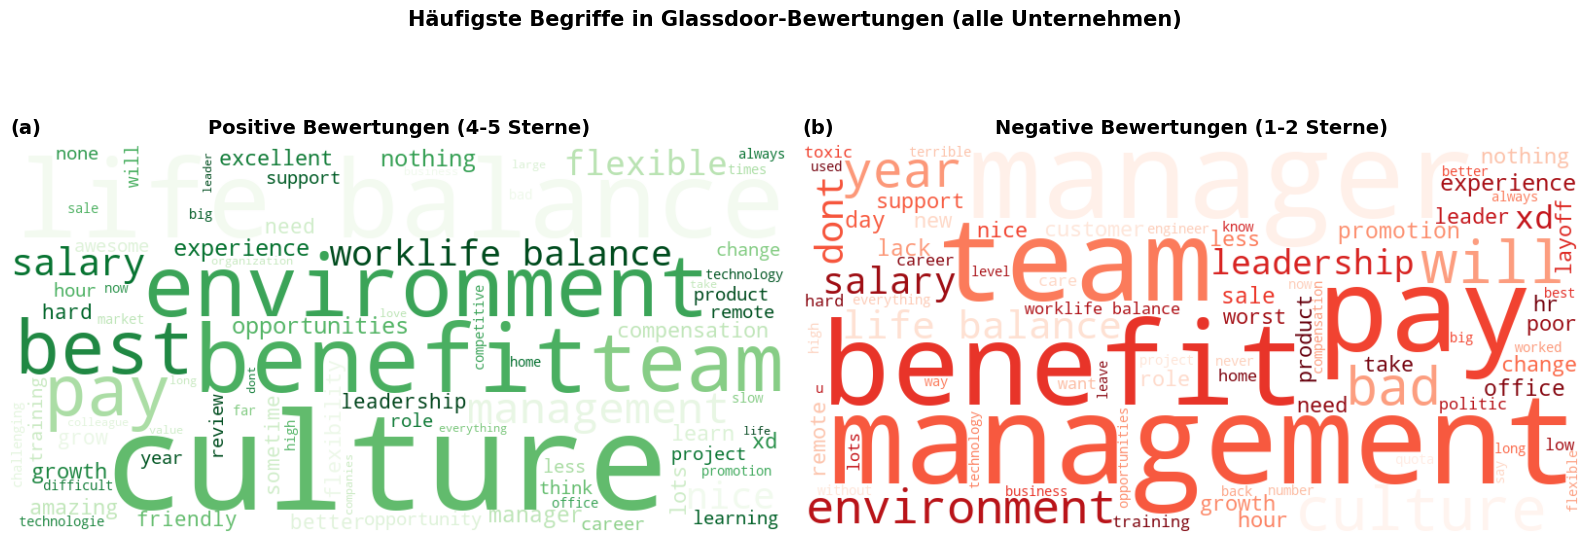


Top 20 Wörter in positive Reviews:
  balance                6686
  culture                6304
  life                   5509
  benefits               3692
  environment            3466
  pay                    2742
  team                   2718
  salary                 2716
  best                   2436
  management             2400
  opportunities          2378
  growth                 2249
  career                 2208
  nice                   1921
  worklife               1860
  flexible               1791
  nothing                1783
  experience             1438
  learn                  1299
  amazing                1271

Top 20 Wörter in negative Reviews:
  management              713
  pay                     529
  culture                 440
  benefits                419
  will                    396
  balance                 373
  team                    355
  bad                     324
  life                    313
  dont                    307
  salary                  29

In [73]:
# ============================================================
# Word Clouds
# ============================================================

# Installation falls nötig (auf Colab):
# !pip install wordcloud -q

from wordcloud import WordCloud
import re

# Alle Reviews laden und zusammenführen
all_reviews = []
for company_name, paths in companies.items():
    df_rev = pd.read_csv(paths["sentiment"])
    df_rev = df_rev[df_rev["year"].between(*YEAR_RANGE)]
    df_rev["company"] = company_name
    all_reviews.append(df_rev)
all_reviews_df = pd.concat(all_reviews, ignore_index=True)

# Stoppwörter erweitern (Standard + Glassdoor-spezifisch)
custom_stopwords = {
    "company", "work", "working", "good", "great", "lot",
    "people", "time", "really", "also", "well", "get",
    "like", "one", "would", "much", "make", "many",
    "things", "even", "still", "overall", "place",
    "job", "employee", "employees", "pros", "cons",
    "AMD", "Nvidia", "Dell", "HP", "Inc",
    "amd", "nvidia", "dell",
}

from wordcloud import STOPWORDS
all_stops = STOPWORDS.union(custom_stopwords)

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

# Word Clouds: Positiv vs. Negativ
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, (label, title, color) in enumerate([
    ("positive", "Positive Bewertungen (4-5 Sterne)", "Greens"),
    ("negative", "Negative Bewertungen (1-2 Sterne)", "Reds"),
]):
    subset = all_reviews_df[all_reviews_df["sentiment_label"] == label]
    text = " ".join(subset["review_text"].apply(clean_text))

    wc = WordCloud(
        width=800, height=400,
        max_words=80,
        stopwords=all_stops,
        colormap=color,
        background_color="white",
        random_state=42,
    ).generate(text)

    axes[i].imshow(wc, interpolation="bilinear")
    axes[i].set_title(title, fontsize=14, fontweight="bold")
    axes[i].axis("off")


# Insert subplot labels (a), (b)
for ax, label in zip(axes.flat, ['(a)', '(b)']):
    ax.set_title(label, loc='left', fontsize=14, fontweight='bold', pad=8)

plt.suptitle("Häufigste Begriffe in Glassdoor-Bewertungen "
             "(alle Unternehmen)",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../results/latex/fig_wordclouds.pdf",
            dpi=300, bbox_inches="tight")
plt.savefig("../results/fig_wordclouds.png",
            dpi=300, bbox_inches="tight")
plt.show()

# Zusätzlich: Top-20 Wörter als Tabelle
from collections import Counter

for label in ["positive", "negative"]:
    subset = all_reviews_df[all_reviews_df["sentiment_label"] == label]
    words = " ".join(subset["review_text"].apply(clean_text)).split()
    words = [w for w in words if w not in all_stops and len(w) > 2]
    top20 = Counter(words).most_common(20)
    print(f"\nTop 20 Wörter in {label} Reviews:")
    for word, count in top20:
        print(f"  {word:<20} {count:>6}")

#### Within-Firm-Analyse

In [31]:
# === PATCH I (NEU) ==========================================
# EINFUEGEN vor "#### Balanced Sample Robustheitsprüfung"
# Vorschlag Markdown-Ueberschrift: "#### Within-Firm-Analyse"
# ============================================================

def fisher_mean(rs):
    """Mittelt Korrelationen ueber die Fisher-z-Transformation."""
    rs = [r for r in rs if r is not None and not np.isnan(r) and abs(r) < 0.9999]
    if not rs:
        return np.nan, 0
    z = np.arctanh(rs)
    zm, n = z.mean(), len(z)
    return np.tanh(zm), n

rows = []
for metric in ANALYSIS_METRICS:
    sub = panel[["company", PRIMARY_SENT, metric]].dropna()
    if len(sub) < 8:
        continue

    # innerhalb jeder Firma zentrieren
    w = sub.copy()
    w["sent_c"]   = w.groupby("company")[PRIMARY_SENT].transform(lambda s: s - s.mean())
    w["metric_c"] = w.groupby("company")[metric].transform(lambda s: s - s.mean())
    w = w[(w.groupby("company")[metric].transform("nunique") > 1)]
    if len(w) < 8 or w["metric_c"].std() == 0:
        continue

    r_within, p_within = pearsonr(w["sent_c"], w["metric_c"])
    r_pool,   p_pool   = pearsonr(sub[PRIMARY_SENT], sub[metric])

    per_co = []
    for co, g in sub.groupby("company"):
        if len(g) >= 4 and g[metric].nunique() > 1:
            per_co.append(pearsonr(g[PRIMARY_SENT], g[metric])[0])
    r_fisher, k = fisher_mean(per_co)

    rows.append({
        "metric": metric, "pillar": all_pillar_maps.get(metric, "Unknown"),
        "n": len(sub),
        "r_pooled": round(r_pool, 3),   "p_pooled": round(p_pool, 4),
        "r_within": round(r_within, 3), "p_within": round(p_within, 4),
        "r_fisher": round(r_fisher, 3) if not np.isnan(r_fisher) else np.nan,
        "k_companies": k,
        "simpson": (not np.isnan(r_within)
                    and np.sign(r_pool) != np.sign(r_within)
                    and abs(r_pool) > 0.15 and abs(r_within) > 0.15),
    })

within = pd.DataFrame(rows).sort_values("r_within", key=abs, ascending=False)

print("WITHIN-FIRM-KORRELATION (firmenintern zentriert) vs. GEPOOLT")
print("=" * 100)
print(f"{'Metrik':<44} {'n':>3} {'r_gepoolt':>10} {'p':>8} "
      f"{'r_within':>9} {'p':>8} {'r_Fisher':>9} {'k':>3}  Simpson")
print("-" * 100)
for _, r in within.iterrows():
    s1 = "*" if r["p_pooled"] < 0.05 else " "
    s2 = "*" if r["p_within"] < 0.05 else " "
    fis = f"{r['r_fisher']:>+9.3f}" if not pd.isna(r["r_fisher"]) else f"{'n.v.':>9}"
    print(f"{r['metric']:<44} {r['n']:>3} {r['r_pooled']:>+10.3f}{s1}"
          f"{r['p_pooled']:>7.4f} {r['r_within']:>+9.3f}{s2}"
          f"{r['p_within']:>7.4f} {fis} {r['k_companies']:>3}"
          f"  {'JA' if r['simpson'] else ''}")

n_simpson = within["simpson"].sum()
print(f"\nSimpson-Fälle (Vorzeichenwechsel gepoolt vs. within): "
      f"{n_simpson} von {len(within)}")
if n_simpson:
    print("Betroffen:")
    for m in within[within["simpson"]]["metric"]:
        print(f"  - {m}")
print("\nInterpretation: Bei diesen Metriken unterscheiden sich die Firmen systematisch")
print("im Niveau BEIDER Variablen. Die gepoolte Korrelation misst dann primär diese")
print("Niveauunterschiede, nicht den Zusammenhang innerhalb der Firmen.")

within.to_csv("../results/within_firm_correlations.csv", index=False)

WITHIN-FIRM-KORRELATION (firmenintern zentriert) vs. GEPOOLT
Metrik                                         n  r_gepoolt        p  r_within        p  r_Fisher   k  Simpson
----------------------------------------------------------------------------------------------------
Renewable Energy Percentage                   20     -0.408  0.0741    -0.598* 0.0054    -0.737   4  
Board Independence                            20     +0.228  0.3335    -0.570* 0.0087    -0.075   4  JA
Women in Workforce                            20     -0.676* 0.0011    -0.524* 0.0177    -0.567   4  
Community Investment (pro Mio. USD)           18     -0.099  0.6955    -0.487* 0.0402    -0.517   4  
Say-on-Pay Approval                           20     +0.199  0.4010    +0.473  0.0751    +0.668   3  
Women in Management                           19     -0.566* 0.0116    -0.444  0.0568    -0.530   4  
Women in Senior Management                    14     -0.580* 0.0296    -0.375  0.1869    -0.613   3  
Community I

#### Balanced Sample Robustheitsprüfung

Zeigt ob der 85% Positiv Bias die Ergebnisse verzerrt. 

In [ ]:
# ============================================================
# Balanced-Sample-Robustheitsprüfung
# ============================================================

from scipy.stats import pearsonr, spearmanr, kendalltau

# --- Balanced Sampling ---
balanced_panels = []

for company_name, paths in companies.items():
    df_rev = pd.read_csv(paths["sentiment"])
    df_rev = df_rev[df_rev["year"].between(*YEAR_RANGE)]

    balanced_yearly = []
    for year in df_rev["year"].unique():
        year_data = df_rev[df_rev["year"] == year]
        pos = year_data[year_data["sentiment_label"] == "positive"]
        neg = year_data[year_data["sentiment_label"] == "negative"]
        neu = year_data[year_data["sentiment_label"] == "neutral"]

        # Minimale Klassengröße bestimmen
        n_min = min(len(pos), len(neg), len(neu))
        if n_min < 5:
            n_min = min(len(pos), len(neg))
            if n_min < 3:
                continue

        # Zufällig gleich viele pro Klasse ziehen
        sampled = pd.concat([
            pos.sample(n=n_min, random_state=42),
            neg.sample(n=n_min, random_state=42),
            neu.sample(n=min(n_min, len(neu)), random_state=42),
        ])
        balanced_yearly.append(sampled)

    if balanced_yearly:
        balanced_df = pd.concat(balanced_yearly)

        yearly_bal = balanced_df.groupby("year").agg(
            n_reviews=("roberta_score", "count"),
            mean_roberta_bal=("roberta_score", "mean"),
        ).reset_index()
        yearly_bal["company"] = company_name
        balanced_panels.append(yearly_bal)

balanced_sent = pd.concat(balanced_panels, ignore_index=True)

# In das bestehende Panel mergen
panel_bal = panel.merge(
    balanced_sent[["company", "year", "mean_roberta_bal", "n_reviews"]],
    on=["company", "year"],
    how="left",
    suffixes=("", "_balanced")
)

# --- Korrelationen vergleichen ---
print("BALANCED-SAMPLE-ROBUSTHEITSPRÜFUNG")
print("=" * 90)
print(f"{'Metrik':<40} {'Original r':>11} {'Balanced r':>11} "
      f"{'Differenz':>10} {'Richtung':>10}")
print("-" * 90)

balanced_results = []
for metric in ANALYSIS_METRICS:
    if metric not in panel_bal.columns:
        continue

    # Original
    valid_orig = panel_bal[[PRIMARY_SENT, metric]].dropna()
    # Balanced
    valid_bal = panel_bal[["mean_roberta_bal", metric]].dropna()

    if len(valid_orig) >= 6 and len(valid_bal) >= 6:
        r_orig, _ = pearsonr(valid_orig[PRIMARY_SENT],
                             valid_orig[metric])
        r_bal, _ = pearsonr(valid_bal["mean_roberta_bal"],
                            valid_bal[metric])
        diff = r_bal - r_orig
        stable = "stabil" if (r_orig > 0) == (r_bal > 0) else "GEWECHSELT"

        balanced_results.append({
            "metric": metric,
            "r_original": r_orig,
            "r_balanced": r_bal,
            "diff": diff,
            "direction": stable
        })

        print(f"{metric:<40} {r_orig:>+11.3f} {r_bal:>+11.3f} "
              f"{diff:>+10.3f} {stable:>10}")

stable_count = sum(1 for c in balanced_results if c["direction"] == "stabil")
switched_count = sum(1 for c in balanced_results
                     if c["direction"] == "GEWECHSELT")
print(f"\nRichtung stabil: {stable_count}/{len(balanced_results)}")
print(f"Richtung gewechselt: {switched_count}/{len(balanced_results)}")

# CSV-Export
pd.DataFrame(balanced_results).to_csv(
    "../results/balanced_sample_vergleich.csv", index=False
)

BALANCED-SAMPLE-ROBUSTHEITSPRÜFUNG
Metrik                                    Original r  Balanced r  Differenz   Richtung
------------------------------------------------------------------------------------------
Renewable Energy Percentage                   -0.408      -0.457     -0.049     stabil
Employee Turnover Rate                        -0.544      -0.206     +0.338     stabil
Women in Workforce                            -0.676      -0.018     +0.657     stabil
Women in Management                           -0.566      -0.136     +0.430     stabil
Women in Senior Management                    -0.580      -0.125     +0.455     stabil
Training Hours per Employee                   -0.060      -0.004     +0.056     stabil
Total Recordable Injury Rate                  -0.203      +0.002     +0.205 GEWECHSELT
Board Independence                            +0.228      -0.065     -0.293 GEWECHSELT
Women on Board                                -0.389      -0.188     +0.202     stabil
CEO 

#### Detrending-Analyse

Adressiert die Zeittrend-Konfundierung.

Falls nach dem Detrending andere Metriken signifikant werden, sind das "echte" ESG-Sentiment-Zusammenhänge.
Falls nichts signifikant bleibt (also wie vorher), bestätigt das meine Untersuchung.

In [ ]:
# ============================================================
# Detrending-Analyse
# Korrelation der Jahresveränderungen statt der Niveaus
# ============================================================

# --- Jahresveränderungen berechnen ---
panel_diff = panel.sort_values(["company", "year"]).copy()

# Differenzen innerhalb jeder Firma
diff_cols = [PRIMARY_SENT] + [m for m in ANALYSIS_METRICS
                               if m in panel.columns]

for col in diff_cols:
    panel_diff[f"d_{col}"] = panel_diff.groupby("company")[col].diff()

# Erste Beobachtung pro Firma hat NaN (kein Vorjahr) -> entfernen
panel_diff = panel_diff.dropna(subset=[f"d_{PRIMARY_SENT}"])

print(f"Detrended Panel: {len(panel_diff)} Beobachtungen "
      f"(Jahresveränderungen)")
print(f"Firmen: {panel_diff['company'].nunique()}")

# --- Korrelationen auf Veränderungen ---
print("\nDETRENDING-ANALYSE: Korrelation der Jahresveränderungen")
print("=" * 100)
print(f"{'Metrik':<40} {'Niveau r':>9} {'Niveau p':>9} "
      f"{'Δ r':>9} {'Δ p':>9} {'Vergleich':>12}")
print("-" * 100)

detrend_results = []
for metric in ANALYSIS_METRICS:
    if metric not in panel.columns:
        continue
    d_metric = f"d_{metric}"
    d_sent = f"d_{PRIMARY_SENT}"

    if d_metric not in panel_diff.columns:
        continue

    # Niveau-Korrelation (zum Vergleich)
    valid_level = panel[[PRIMARY_SENT, metric]].dropna()
    # Differenz-Korrelation
    valid_diff = panel_diff[[d_sent, d_metric]].dropna()

    if len(valid_level) >= 6 and len(valid_diff) >= 6:
        r_level, p_level = pearsonr(valid_level[PRIMARY_SENT],
                                     valid_level[metric])
        r_diff, p_diff = pearsonr(valid_diff[d_sent],
                                   valid_diff[d_metric])

        # Vergleich
        if abs(r_diff) > abs(r_level):
            comp = "STÄRKER"
        elif abs(r_diff) < abs(r_level) * 0.5:
            comp = "SCHWÄCHER"
        else:
            comp = "ähnlich"

        sig_level = "*" if p_level < 0.05 else ""
        sig_diff = "*" if p_diff < 0.05 else ""

        detrend_results.append({
            "metric": metric,
            "r_level": r_level,
            "p_level": p_level,
            "r_diff": r_diff,
            "p_diff": p_diff,
            "comparison": comp
        })

        print(f"{metric:<40} {r_level:>+8.3f}{sig_level:1s} "
              f"{p_level:>8.4f} {r_diff:>+8.3f}{sig_diff:1s} "
              f"{p_diff:>8.4f} {comp:>12}")

# Zusammenfassung
stronger = sum(1 for d in detrend_results
               if d["comparison"] == "STÄRKER")
weaker = sum(1 for d in detrend_results
             if d["comparison"] == "SCHWÄCHER")
similar = sum(1 for d in detrend_results
              if d["comparison"] == "ähnlich")
sig_after = sum(1 for d in detrend_results if d["p_diff"] < 0.05)

print(f"\nNach Detrending:")
print(f"  Stärker geworden: {stronger}")
print(f"  Schwächer geworden: {weaker}")
print(f"  Ähnlich geblieben: {similar}")
print(f"  Signifikant (p<0.05): {sig_after}")

pd.DataFrame(detrend_results).to_csv(
    "../results/detrending_vergleich.csv", index=False
)

Detrended Panel: 16 Beobachtungen (Jahresveränderungen)
Firmen: 4

DETRENDING-ANALYSE: Korrelation der Jahresveränderungen
Metrik                                    Niveau r  Niveau p       Δ r       Δ p    Vergleich
----------------------------------------------------------------------------------------------------
Renewable Energy Percentage                -0.408    0.0741   -0.389    0.1368      ähnlich
Employee Turnover Rate                     -0.544*   0.0360   +0.606*   0.0366      STÄRKER
Women in Workforce                         -0.676*   0.0011   +0.097    0.7205    SCHWÄCHER
Women in Management                        -0.566*   0.0116   +0.208    0.4751    SCHWÄCHER
Women in Senior Management                 -0.580*   0.0296   -0.304    0.3634      ähnlich
Training Hours per Employee                -0.060    0.8388   +0.029    0.9358    SCHWÄCHER
Total Recordable Injury Rate               -0.203    0.3905   +0.202    0.4523      ähnlich
Board Independence                    

#### Keyword-basierte Aspektanalyse

Korreliert aspektspezifisches Sentiment besser als globales?

Falls Management-Sentiment stärker mit Governance korreliert als das globale Sentiment, \
oder Diversity-Sentiment stärker mit Frauenanteil, wäre das ein starkes Ergebnis: \
Der Ansatz funktioniert, nur die Auflösung war zu grob. \
Falls nicht, stützt es die Nullhypothese.

In [ ]:
# ============================================================
# Keyword-basierte Aspektanalyse
# ============================================================

# --- Aspekt-Wörterbücher definieren ---

ASPECT_KEYWORDS = {
    "management": [
        "management", "manager", "leadership", "leader",
        "director", "executive", "ceo", "boss", "supervisor",
        "vp", "senior leadership", "upper management",
        "decision making", "strategy", "vision"
    ],
    "compensation": [
        "salary", "pay", "compensation", "bonus", "stock",
        "benefits", "401k", "equity", "rsu", "raise",
        "package", "perks", "insurance", "retirement",
        "underpaid", "overpaid", "competitive pay"
    ],
    "diversity": [
        "diversity", "inclusion", "inclusive", "dei",
        "women", "minority", "gender", "equity", "belonging",
        "representation", "equal opportunity", "diverse"
    ],
    "work_life_balance": [
        "work-life", "work life", "balance", "overtime",
        "hours", "flexible", "remote", "burnout", "vacation",
        "pto", "hybrid", "weekends", "on-call"
    ],
    "career": [
        "growth", "career", "promotion", "learning",
        "development", "training", "opportunity", "advance",
        "mentor", "skill", "upward mobility"
    ],
    "safety": [
        "safety", "safe", "hazard", "injury", "accident",
        "health", "osha", "protective", "dangerous",
        "incident", "workplace safety"
    ],

}

# --- Reviews laden und Aspekte taggen ---
all_reviews = []
for company_name, paths in companies.items():
    df_rev = pd.read_csv(paths["sentiment"])
    df_rev = df_rev[df_rev["year"].between(*YEAR_RANGE)]
    df_rev["company"] = company_name
    all_reviews.append(df_rev)
all_reviews_df = pd.concat(all_reviews, ignore_index=True)

# Aspekt-Flags setzen
for aspect, keywords in ASPECT_KEYWORDS.items():
    pattern = "|".join(keywords)
    all_reviews_df[f"mentions_{aspect}"] = (
        all_reviews_df["review_text"]
        .str.lower()
        .str.contains(pattern, regex=True, na=False)
    )


# Übersicht: wie viele Reviews erwähnen jeden Aspekt?
print("ASPEKT-ABDECKUNG")
print("=" * 50)
for aspect in ASPECT_KEYWORDS:
    n = all_reviews_df[f"mentions_{aspect}"].sum()
    pct = n / len(all_reviews_df) * 100
    print(f"  {aspect:<20} {n:>6} Reviews ({pct:.1f}%)")

# --- Aspekt-Sentiment pro Firma und Jahr aggregieren ---

aspect_panels = {}

for aspect in ASPECT_KEYWORDS:
    subset = all_reviews_df[all_reviews_df[f"mentions_{aspect}"]]

    if len(subset) < 50:
        print(f"\n  WARNUNG: {aspect} hat nur {len(subset)} "
              f"Reviews, überspringe.")
        continue

    aspect_yearly = subset.groupby(["company", "year"]).agg(
        **{f"sentiment_{aspect}": ("roberta_score", "mean"),
           f"n_{aspect}": ("roberta_score", "count")}
    ).reset_index()

    aspect_panels[aspect] = aspect_yearly

# In das Hauptpanel mergen
panel_aspect = panel.copy()
for aspect, asp_df in aspect_panels.items():
    panel_aspect = panel_aspect.merge(
        asp_df, on=["company", "year"], how="left"
    )

# --- Aspekt-Sentiment mit passenden ESG-Metriken korrelieren ---
ASPECT_ESG_MAPPING = {
    "management": [
        "Board Independence", "Say-on-Pay Approval",
        "CEO Pay Ratio", "Effective Tax Rate"
    ],
    "compensation": [
        "CEO Pay Ratio", "Say-on-Pay Approval"
    ],
    "diversity": [
        "Women in Workforce", "Women in Management",
        "Women in Senior Management", "Women on Board"
    ],
    "work_life_balance": [
        "Employee Turnover Rate",
        "Total Recordable Injury Rate"
    ],
    "career": [
        "Training Hours per Employee"
    ],
    "safety": [
        "Total Recordable Injury Rate"
    ],
    "environment": [
        "Scope 1 GHG Emissions (pro Mio. USD)"
    ]
}

print("\n\nASPEKT-KORRELATIONEN vs. GLOBALE KORRELATIONEN")
print("=" * 95)
print(f"{'Aspekt':<15} {'ESG-Metrik':<30} "
      f"{'n_g':>4} {'Global r':>9} {'n_a':>4} {'Aspekt r':>9} "
      f"{'p_a':>8} {'Besser?':>8}")
print("-" * 95)

aspect_results = []

# --- Sicherung: nur Metriken verwenden, die in der Analyse sind ---
ASPECT_ESG_MAPPING = {
    a: [m for m in ms if m in ANALYSIS_METRICS]
    for a, ms in ASPECT_ESG_MAPPING.items()
}
_paarungen = sum(len(v) for v in ASPECT_ESG_MAPPING.values())
print(f"Metrik-Aspekt-Paarungen nach Filterung: {_paarungen}\n")

for aspect, esg_metrics_list in ASPECT_ESG_MAPPING.items():
    sent_col = f"sentiment_{aspect}"
    if sent_col not in panel_aspect.columns:
        continue

    for metric in esg_metrics_list:
        if metric not in panel_aspect.columns:
            continue

        # Globale Korrelation
        valid_global = panel_aspect[
            [PRIMARY_SENT, metric]
        ].dropna()
        # Aspekt-Korrelation
        valid_aspect = panel_aspect[
            [sent_col, metric]
        ].dropna()

        if len(valid_global) >= 6 and len(valid_aspect) >= 6:
            r_global, p_global = pearsonr(
                valid_global[PRIMARY_SENT],
                valid_global[metric]
            )
            r_aspect, p_aspect = pearsonr(
                valid_aspect[sent_col],
                valid_aspect[metric]
            )

            diff = abs(r_aspect) - abs(r_global)
            better = "JA" if diff > 0 else "nein"

            aspect_results.append({
                "aspect": aspect,
                "metric": metric,
                "n_global": len(valid_global),
                "r_global": r_global,
                "p_global": p_global,
                "n_aspect": len(valid_aspect),
                "r_aspect": r_aspect,
                "p_aspect": p_aspect,
                "diff": diff,
                "better": better
            })

            print(f"{aspect:<15} {metric:<30} "
                  f"{len(valid_global):>4} {r_global:>+9.3f} "
                  f"{len(valid_aspect):>4} {r_aspect:>+9.3f} "
                  f"{p_aspect:>8.3f} {better:>8}")


# Zusammenfassung
better_count = sum(1 for a in aspect_results if a["better"] == "JA")
total_count = len(aspect_results)
print(f"\nAspekt-Sentiment stärker als global: "
      f"{better_count}/{total_count} Paarungen")

pd.DataFrame(aspect_results).to_csv(
    "../results/aspekt_korrelationen.csv", index=False
)

ASPEKT-ABDECKUNG
  management             7801 Reviews (25.8%)
  compensation          12718 Reviews (42.1%)
  diversity              1281 Reviews (4.2%)
  work_life_balance     11661 Reviews (38.6%)
  career                 8891 Reviews (29.4%)
  safety                  744 Reviews (2.5%)


ASPEKT-KORRELATIONEN vs. GLOBALE KORRELATIONEN
Aspekt          ESG-Metrik                      n_g  Global r  n_a  Aspekt r      p_a  Besser?
-----------------------------------------------------------------------------------------------
Metrik-Aspekt-Paarungen nach Filterung: 15

management      Board Independence               20    +0.228   20    +0.147    0.535     nein
management      Say-on-Pay Approval              20    +0.199   20    +0.146    0.539     nein
management      CEO Pay Ratio                    20    -0.285   20    -0.422    0.064       JA
management      Effective Tax Rate               20    +0.088   20    +0.031    0.898     nein
compensation    CEO Pay Ratio                

#### Quartalsgranularität 

Weiterer Robustheitstest durch Unterteilung von Angestelltenbewertungen in Quartale anstatt Jahre. \
~20 Beobachtungen werden zu ~80 und könnten damit könnten bisher nicht-signifikante Korrelationen über die Schwelle kommen. \
Und vielleicht ergeben sich auch seasonale Muster.

In [ ]:
# ============================================================
# Quartalsgranularität
# ============================================================

# --- Sentiment auf Quartalsebene aggregieren ---
quarterly_panels = []

for company_name, paths in companies.items():
    df_rev = pd.read_csv(paths["sentiment"])
    df_rev = df_rev[df_rev["year"].between(*YEAR_RANGE)]

    # Quartal aus Datum ableiten
    df_rev["date"] = pd.to_datetime(df_rev["date"], errors="coerce")
    df_rev["quarter"] = df_rev["date"].dt.quarter
    df_rev["year_quarter"] = (
        df_rev["year"].astype(str) + "-Q" +
        df_rev["quarter"].astype(str)
    )

    quarterly_sent = df_rev.groupby(["year", "quarter"]).agg(
        n_reviews=("roberta_score", "count"),
        mean_roberta_q=("roberta_score", "mean"),
        mean_vader_q=("vader_score", "mean"),
        mean_stars_q=("overall_stars", "mean"),
    ).reset_index()
    quarterly_sent["company"] = company_name

    # Mindestens 10 Reviews pro Quartal
    quarterly_sent = quarterly_sent[
        quarterly_sent["n_reviews"] >= 10
    ]

    quarterly_panels.append(quarterly_sent)

quarterly_panel = pd.concat(quarterly_panels, ignore_index=True)
print(f"Quartals-Panel: {len(quarterly_panel)} Beobachtungen")
print(f"(vs. {len(panel)} auf Jahresebene)")

# --- ESG-Daten auf Quartale interpolieren ---
# ESG-Daten sind jährlich -> linear auf Quartale verteilen
quarterly_with_esg = quarterly_panel.copy()

for metric in ANALYSIS_METRICS:
    if metric not in panel.columns:
        continue

    # Für jede Firma: Jahreswerte auf Quartale interpolieren
    for company in quarterly_with_esg["company"].unique():
        yearly_vals = panel[panel["company"] == company][
            ["year", metric]
        ].dropna().sort_values("year")

        if len(yearly_vals) < 2:
            continue

        # Interpolation: Jahresmitte (Q2/Q3) als Ankerpunkt
        for _, qrow in quarterly_with_esg[
            quarterly_with_esg["company"] == company
        ].iterrows():
            y = qrow["year"]
            q = qrow["quarter"]

            # Finde den Jahreswert und ggf. den Vorjahres-/Folgejahreswert
            current = yearly_vals[yearly_vals["year"] == y][metric]
            prev = yearly_vals[yearly_vals["year"] == y - 1][metric]
            nxt = yearly_vals[yearly_vals["year"] == y + 1][metric]

            if len(current) == 0:
                continue

            val = current.iloc[0]

            # Einfache lineare Interpolation innerhalb des Jahres
            if q <= 2 and len(prev) > 0:
                weight = (q + 1) / 4  # Q1=0.5, Q2=0.75
                val = prev.iloc[0] * (1 - weight) + val * weight
            elif q >= 3 and len(nxt) > 0:
                weight = (q - 2) / 4  # Q3=0.25, Q4=0.5
                val = val * (1 - weight) + nxt.iloc[0] * weight

            idx = qrow.name
            quarterly_with_esg.loc[idx, metric] = val

# --- Quartals-Korrelationen berechnen ---
print("\nQUARTALS-KORRELATIONEN vs. JAHRES-KORRELATIONEN")
print("=" * 90)
print(f"{'Metrik':<40} {'Jahr r':>8} {'Jahr p':>8} "
      f"{'Quartal r':>10} {'Quartal p':>10} {'n_q':>5}")
print("-" * 90)

quarterly_results = []
for metric in ANALYSIS_METRICS:
    if metric not in quarterly_with_esg.columns:
        continue

    # Jahreskorrelation (zum Vergleich)
    valid_y = panel[[PRIMARY_SENT, metric]].dropna()
    # Quartalskorrelation
    valid_q = quarterly_with_esg[
        ["mean_roberta_q", metric]
    ].dropna()

    if len(valid_y) >= 6 and len(valid_q) >= 10:
        r_y, p_y = pearsonr(valid_y[PRIMARY_SENT], valid_y[metric])
        r_q, p_q = pearsonr(valid_q["mean_roberta_q"],
                            valid_q[metric])

        quarterly_results.append({
            "metric": metric,
            "r_yearly": r_y,
            "p_yearly": p_y,
            "r_quarterly": r_q,
            "p_quarterly": p_q,
            "n_quarterly": len(valid_q)
        })

        sig_y = "*" if p_y < 0.05 else " "
        sig_q = "*" if p_q < 0.05 else " "
        print(f"{metric:<40} {r_y:>+7.3f}{sig_y} {p_y:>8.4f} "
              f"{r_q:>+9.3f}{sig_q} {p_q:>10.4f} {len(valid_q):>5}")

pd.DataFrame(quarterly_results).to_csv(
    "../results/quarterly_correlations.csv", index=False
)

Quartals-Panel: 80 Beobachtungen
(vs. 20 auf Jahresebene)

QUARTALS-KORRELATIONEN vs. JAHRES-KORRELATIONEN
Metrik                                     Jahr r   Jahr p  Quartal r  Quartal p   n_q
------------------------------------------------------------------------------------------
Renewable Energy Percentage               -0.408    0.0741    -0.346*     0.0017    80
Employee Turnover Rate                    -0.544*   0.0360    -0.537*     0.0000    60
Women in Workforce                        -0.676*   0.0011    -0.614*     0.0000    80
Women in Management                       -0.566*   0.0116    -0.520*     0.0000    76
Women in Senior Management                -0.580*   0.0296    -0.513*     0.0001    56
Training Hours per Employee               -0.060    0.8388    -0.059      0.6682    56
Total Recordable Injury Rate              -0.203    0.3905    -0.183      0.1039    80
Board Independence                        +0.228    0.3335    +0.206      0.0671    80
Women on Board     

#### Multi-Modell-Robustheitsprüfung

In [ ]:
# ============================================================
# ulti-Modell-Robustheitsprüfung
# ============================================================
available = [m for m in SENT_MODELS if m in panel.columns]
print(f"Verfuegbare Sentimentmaße: {available}")
missing = [m for m in SENT_MODELS if m not in panel.columns]
if missing:
    print(f"FEHLT im Panel: {missing} - Patch B eingebaut und neu ausgefuehrt?")

rows = []
for metric in ANALYSIS_METRICS:
    entry = {"metric": metric, "pillar": all_pillar_maps.get(metric, "Unknown")}
    rs = []
    for model in available:
        v = panel[[model, metric]].dropna()
        if len(v) < 6 or v[metric].nunique() < 2:
            entry[model] = np.nan
            continue
        r, p = pearsonr(v[model], v[metric])
        entry[model] = round(r, 3)
        entry[f"{model}_p"] = round(p, 4)
        entry["n"] = len(v)
        rs.append(r)
    if rs:
        entry["signs_agree"] = len(set(np.sign(rs))) == 1
        entry["r_spread"] = round(max(rs) - min(rs), 3)
        rows.append(entry)

multimodel = pd.DataFrame(rows).sort_values(
    "mean_roberta", key=abs, ascending=False
)

print("\nMULTI-MODELL-ROBUSTHEIT: Korrelation je Sentimentmaß")
print("=" * 104)
hdr = f"{'Metrik':<44} {'n':>3}"
for m in available:
    hdr += f" {m.replace('mean_',''):>10}"
hdr += f" {'Spanne':>8} {'gleich':>7}"
print(hdr)
print("-" * 104)
for _, r in multimodel.iterrows():
    line = f"{r['metric']:<44} {int(r.get('n', 0)):>3}"
    for m in available:
        line += f" {r[m]:>+10.3f}" if not pd.isna(r[m]) else f" {'n.v.':>10}"
    line += f" {r['r_spread']:>8.3f} {('JA' if r['signs_agree'] else 'NEIN'):>7}"
    print(line)

strong = multimodel[multimodel["mean_roberta"].abs() >= 0.30]
weak   = multimodel[multimodel["mean_roberta"].abs() <  0.30]
print(f"\nStarke Korrelationen (|r| >= 0,30): "
      f"{strong['signs_agree'].sum()}/{len(strong)} richtungsstabil ueber alle Modelle")
print(f"Schwache Korrelationen (|r| < 0,30): "
      f"{weak['signs_agree'].sum()}/{len(weak)} richtungsstabil")
print(f"Mittlere Spannweite ueber die Modelle: "
      f"{multimodel['r_spread'].mean():.3f}")

multimodel.to_csv("../results/multimodel_robustness.csv", index=False)

Verfuegbare Sentimentmaße: ['mean_roberta', 'mean_vader', 'mean_siebert', 'mean_nlptown']

MULTI-MODELL-ROBUSTHEIT: Korrelation je Sentimentmaß
Metrik                                         n    roberta      vader    siebert    nlptown   Spanne  gleich
--------------------------------------------------------------------------------------------------------
Women in Workforce                            20     -0.676     -0.333     -0.605     -0.609    0.342      JA
Scope 1 GHG Emissions (pro Mio. USD)          20     -0.639     -0.360     -0.543     -0.631    0.279      JA
Women in Senior Management                    14     -0.580     -0.267     -0.507     -0.497    0.313      JA
Women in Management                           19     -0.566     -0.268     -0.493     -0.495    0.298      JA
Employee Turnover Rate                        15     -0.544     -0.267     -0.580     -0.557    0.313      JA
Renewable Energy Percentage                   20     -0.408     -0.347     -0.341     -0.32

#### Zentraltabelle: Vergleich der Analyseebenen

In [ ]:
def _as_df(obj):
    """Akzeptiert DataFrame oder Liste von Dicts."""
    if obj is None:
        return None
    if isinstance(obj, pd.DataFrame):
        return obj
    if isinstance(obj, (list, tuple)) and obj and isinstance(obj[0], dict):
        return pd.DataFrame(obj)
    return None

def _lookup(obj, metric, *cols, pick_max_abs=False):
    df = _as_df(obj)
    if df is None or "metric" not in df.columns:
        return np.nan
    rows = df[df["metric"] == metric]
    if rows.empty:
        return np.nan
    col = next((c for c in cols if c in df.columns), None)
    if col is None:
        return np.nan
    vals = rows[col].dropna()
    if vals.empty:
        return np.nan
    return vals.loc[vals.abs().idxmax()] if pick_max_abs else vals.iloc[0]

# Metriken der Tabelle: stärkste gepoolte plus die beiden Kernbefunde
focus = list(pooled_corr.head(8)["metric"])
for extra in ["Employee Turnover Rate", "Say-on-Pay Approval",
              "Board Independence"]:
    if extra in ANALYSIS_METRICS and extra not in focus:
        focus.append(extra)

rows = []
for m in focus:
    rows.append({
        "Metrik": m,
        "Säule": all_pillar_maps.get(m, "?")[:3],
        "Niveau":   _lookup(pooled_corr, m, "pearson_r"),
        "Within":   _lookup(globals().get("within"), m, "r_fisher", "r_within"),
        "Balanced": _lookup(balanced_results, m, "r_balanced"),
        "Delta":    _lookup(detrend_results,  m, "r_diff", "delta_r"),
        "Aspekt":   _lookup(aspect_results,   m, "r_aspect", pick_max_abs=True),
    })

levels = pd.DataFrame(rows)
EBENEN = ["Niveau", "Within", "Balanced", "Delta", "Aspekt"]

print("ZENTRALTABELLE: dieselbe Metrik auf fuenf Analyseebenen")
print("=" * 104)
print(f"{'Metrik':<40} {'S':<4}" + "".join(f"{e:>11}" for e in EBENEN)
      + "  Wechsel")
print("-" * 104)

n_flip = 0
for _, r in levels.iterrows():
    vals = [r[e] for e in EBENEN]
    present = [v for v in vals if pd.notna(v) and abs(v) > 0.05]
    flips = len({np.sign(v) for v in present}) > 1
    n_flip += int(flips)
    line = f"{r['Metrik']:<40} {r['Säule']:<4}"
    for v in vals:
        line += f" {v:>+10.3f}" if pd.notna(v) else f" {'--':>10}"
    line += f"  {'JA' if flips else ''}"
    print(line)

fehlend = [e for e in EBENEN if levels[e].isna().all()]
if fehlend:
    print(f"\nWARNUNG: Spalten ohne jeden Wert: {fehlend}")
    print("  Die zugehoerige Analysezelle wurde nicht ausgefuehrt oder das")
    print("  Ergebnisobjekt heisst anders. Reihenfolge: Within -> Balanced")
    print("  -> Detrending -> Aspektanalyse -> diese Zelle.")

print(f"\nMetriken mit Vorzeichenwechsel zwischen mindestens zwei Ebenen: "
      f"{n_flip} von {len(levels)}")
print("\nDies ist der zentrale Befund der Arbeit: die Wahl der Analyseebene")
print("entscheidet ueber Vorzeichen und Signifikanz - bei identischen Rohdaten.")

# --- LaTeX-Export ---
import os
os.makedirs("../results/latex", exist_ok=True)

def _fmt(v):
    return "--" if pd.isna(v) else f"${v:+.3f}$".replace(".", "{,}")

zeilen = [
    r"\begin{table}[H]",
    r"  \centering",
    r"  \small",
    r"  \caption{Korrelation zwischen Mitarbeiterstimmung und ausgewählten "
    r"ESG-Metriken auf fünf Analyseebenen}",
    r"  \label{tab:analyseebenen}",
    r"  \begin{tabular}{l l r r r r r}",
    r"    \toprule",
    r"    \textbf{Metrik} & \textbf{Säule} & \textbf{Niveau} & "
    r"\textbf{Within} & \textbf{Balanced} & $\Delta$ & \textbf{Aspekt} \\",
    r"    \midrule",
]
for _, r in levels.iterrows():
    werte = " & ".join(_fmt(r[e]) for e in EBENEN)
    zeilen.append(f"    {r['Metrik']} & {r['Säule']} & {werte} " + r"\\")
zeilen += [
    r"    \bottomrule",
    r"  \end{tabular}",
    r"  \par\vspace{0.3cm}",
    r"  {\footnotesize\textit{Anmerkung:} Niveau = gepoolte Korrelation; "
    r"Within = Fisher-gemittelter Einzelunternehmenskoeffizient; "
    r"Balanced = klassenbalancierte Jahresmittelwerte; "
    r"$\Delta$ = Korrelation der Jahresveränderungen; "
    r"Aspekt = Sentiment nur aus thematisch passenden Reviews "
    r"(betragsmäßig stärkster Aspekt). "
    r"-- = auf dieser Ebene nicht berechenbar.}",
    r"\end{table}",
]

with open("../results/latex/tab_analyseebenen.tex", "w", encoding="utf-8") as f:
    f.write("\n".join(zeilen) + "\n")

levels.to_csv("../results/analyseebenen.csv", index=False)
print("\nGespeichert: ../results/latex/tab_analyseebenen.tex")

ZENTRALTABELLE: dieselbe Metrik auf fuenf Analyseebenen
Metrik                                   S        Niveau     Within   Balanced      Delta     Aspekt  Wechsel
--------------------------------------------------------------------------------------------------------
Women in Workforce                       Soc      -0.676     -0.567     -0.018     +0.097     +0.193  JA
Scope 1 GHG Emissions (pro Mio. USD)     Env      -0.639     -0.207     +0.072     -0.191         --  JA
Women in Senior Management               Soc      -0.580     -0.613     -0.125     -0.304     +0.226  JA
Women in Management                      Soc      -0.566     -0.530     -0.136     +0.208     +0.310  JA
Employee Turnover Rate                   Soc      -0.544     +0.743     -0.206     +0.606     -0.386  JA
Renewable Energy Percentage              Env      -0.408     -0.737     -0.457     -0.389         --  
Hazardous Waste (pro Mio. USD)           Env      -0.389     -0.352     +0.124     +0.002         -- 

#### Abschlussprüfung: Konsistenz aller Ergebnisse

In [ ]:
# ============================================================
# ABSCHLUSSPRÜFUNG - nach einem kompletten Durchlauf ausfuehren.
# Vergleicht die Kennzahlen, die in der Arbeit mehrfach vorkommen.
# ============================================================
print("KENNZAHLEN FUER DIE ARBEIT")
print("=" * 66)

def _n(obj):
    if obj is None: return None
    return len(pd.DataFrame(obj)) if not isinstance(obj, pd.DataFrame) else len(obj)

k = {}
k["Analysevariablen"] = len(ANALYSIS_METRICS)
k["davon unabhängig"] = len(ANALYSIS_METRICS) - len(NORMALIZE_BOTH)
k["Ausgeschlossene Metriken"] = len(EXCLUDED_METRICS)
k["Unternehmen-Jahre"] = len(panel)

if "pooled_corr" in globals():
    k["signifikant p<0,05"] = int((pooled_corr["pearson_p"] < 0.05).sum())
    if "p_fdr" in pooled_corr.columns:
        k["signifikant q<0,05 (FDR)"] = int((pooled_corr["p_fdr"] < 0.05).sum())
    k["Drei-Methoden-Uebereinstimmung %"] = round(
        (pooled_corr["methods_agree"] == "YES").mean() * 100)

if "consistency" in globals():
    k["konsistent alle vier Firmen"] = int(consistency["strict"].sum())
    k["Konsistenzquote %"] = round(consistency["strict"].mean() * 100)

if "within" in globals():
    k["Simpson-Fälle"] = int(within["simpson"].sum())

bal = pd.DataFrame(balanced_results) if "balanced_results" in globals() else None
if bal is not None and "direction" in bal.columns:
    k["Balanced: Richtung gewechselt"] = int(
        (bal["direction"] == "GEWECHSELT").sum())
    k["Balanced: geprueft"] = len(bal)

det = pd.DataFrame(detrend_results) if "detrend_results" in globals() else None
if det is not None and "p_diff" in det.columns:
    k["Detrending: signifikant"] = int((det["p_diff"] < 0.05).sum())

asp = pd.DataFrame(aspect_results) if "aspect_results" in globals() else None
if asp is not None:
    k["Aspekt-Paarungen"] = len(asp)
    if "better" in asp.columns:
        k["Aspekt stärker als global"] = int((asp["better"] == "JA").sum())

for name, val in k.items():
    print(f"  {name:<36} {val}")

print("\n" + "=" * 66)
print("ABGLEICH MIT DEN WERTEN IN DER ARBEIT")
print("=" * 66)
soll = {
    "Analysevariablen": 30, "davon unabhängig": 25,
    "Unternehmen-Jahre": 20, "signifikant p<0,05": 5,
    "signifikant q<0,05 (FDR)": 2, "Drei-Methoden-Uebereinstimmung %": 87,
    "konsistent alle vier Firmen": 5, "Konsistenzquote %": 17,
    "Simpson-Fälle": 7, "Balanced: Richtung gewechselt": 10,
    "Detrending: signifikant": 3, "Aspekt-Paarungen": 14,
    "Aspekt stärker als global": 1,
}
abw = 0
for name, erwartet in soll.items():
    ist = k.get(name)
    if ist is None:
        print(f"  {name:<36} nicht berechnet")
    elif ist == erwartet:
        print(f"  {name:<36} {ist:>4}  ok")
    else:
        abw += 1
        print(f"  {name:<36} {ist:>4}  ABWEICHUNG (Arbeit: {erwartet})")

print(f"\n{abw} Abweichung(en).")
if abw == 0:
    print("Alle Kennzahlen stimmen mit dem Stand der Arbeit ueberein.")
else:
    print("Bei Abweichungen: betroffene Zelle erneut pruefen, bevor der")
    print("Wert in der Arbeit geändert wird.")

KENNZAHLEN FUER DIE ARBEIT
  Analysevariablen                     30
  davon unabhängig                     25
  Ausgeschlossene Metriken             7
  Unternehmen-Jahre                    20
  signifikant p<0,05                   5
  signifikant q<0,05 (FDR)             2
  Drei-Methoden-Uebereinstimmung %     87
  konsistent alle vier Firmen          5
  Konsistenzquote %                    17
  Simpson-Fälle                        7
  Balanced: Richtung gewechselt        10
  Balanced: geprueft                   30
  Detrending: signifikant              3
  Aspekt-Paarungen                     14
  Aspekt stärker als global            1

ABGLEICH MIT DEN WERTEN IN DER ARBEIT
  Analysevariablen                       30  ok
  davon unabhängig                       25  ok
  Unternehmen-Jahre                      20  ok
  signifikant p<0,05                      5  ok
  signifikant q<0,05 (FDR)                2  ok
  Drei-Methoden-Uebereinstimmung %       87  ok
  konsistent alle vier 

In [39]:
# =============================================================================
# ZELLE 1 — Zellgrößen der Balanced-Sample-Analyse
# Liefert N_MIN und FIRMA/JAHR für den Textbaustein 3a.
# =============================================================================
print("ZELLGRÖSSEN DER BALANCIERTEN STICHPROBE")
print("=" * 74)
print(f"{'Firma':<8} {'Jahr':>5} {'gesamt':>8} {'neg':>6} {'neu':>6} "
      f"{'pos':>6} {'je Klasse':>10} {'balanciert':>11}")
print("-" * 74)

frames = []
for name, paths in companies.items():
    d = pd.read_csv(paths["sentiment"])
    d["company"] = name
    frames.append(d)
sent_all = pd.concat(frames, ignore_index=True)


zellen = []
for (co, yr), grp in sent_all.groupby(["company", "year"]):
    if not (YEAR_RANGE[0] <= yr <= YEAR_RANGE[1]):
        continue
    counts = grp["sentiment_label"].value_counts()
    neg = int(counts.get("negative", 0))
    neu = int(counts.get("neutral", 0))
    pos = int(counts.get("positive", 0))
    k = min(neg, neu, pos)
    zellen.append({"company": co, "year": yr, "gesamt": len(grp),
                   "neg": neg, "neutral": neu, "pos": pos,
                   "je_klasse": k, "balanciert": 3 * k})
    print(f"{co:<8} {yr:>5} {len(grp):>8} {neg:>6} {neu:>6} {pos:>6} "
          f"{k:>10} {3*k:>11}")

zdf = pd.DataFrame(zellen)
mn = zdf.loc[zdf["je_klasse"].idxmin()]
print(f"\nKleinste Zelle: {mn['je_klasse']} Reviews je Klasse "
      f"({mn['company']} {mn['year']}, {mn['balanciert']} insgesamt "
      f"statt {mn['gesamt']})")
print(f"Median über alle Zellen: {zdf['je_klasse'].median():.0f} je Klasse")
print(f"Reviews insgesamt: {zdf['gesamt'].sum()} unbalanciert, "
      f"{zdf['balanciert'].sum()} balanciert "
      f"({zdf['balanciert'].sum()/zdf['gesamt'].sum()*100:.1f} %)")


ZELLGRÖSSEN DER BALANCIERTEN STICHPROBE
Firma     Jahr   gesamt    neg    neu    pos  je Klasse  balanciert
--------------------------------------------------------------------------
AMD       2020      186     19     28    139         19          57
AMD       2021      426     29     45    352         29          87
AMD       2022      522     26     63    433         26          78
AMD       2023      567     37     72    458         37         111
AMD       2024      675     51    116    508         51         153
DELL      2020     2512    138    407   1967        138         414
DELL      2021     5169    339    724   4106        339        1017
DELL      2022     4529    250    573   3706        250         750
DELL      2023     3741    311    605   2825        311         933
DELL      2024     3882    480    821   2581        480        1440
HP        2020      805     57    141    607         57         171
HP        2021     1574     80    244   1250         80         240
H

In [ ]:
# =============================================================================
# ZELLE 2 — Inversvarianz-gewichtete Korrelation
# Liefert DELTA_MAX für den Textbaustein 3b.
# Setzt voraus, dass Patch B gelaufen ist (Spalte se_roberta im Panel).
# =============================================================================
if "se_roberta" not in panel.columns:
    print("se_roberta fehlt im Panel - Patch B einbauen und Cell 2 neu laufen.")
else:
    def gewichtete_korrelation(x, y, w):
        """Pearson-Korrelation mit Beobachtungsgewichten w."""
        w = np.asarray(w, dtype=float)
        w = w / w.sum()
        mx, my = np.sum(w * x), np.sum(w * y)
        cov = np.sum(w * (x - mx) * (y - my))
        sx = np.sqrt(np.sum(w * (x - mx) ** 2))
        sy = np.sqrt(np.sum(w * (y - my) ** 2))
        return cov / (sx * sy) if sx > 0 and sy > 0 else np.nan

    rows = []
    for metric in ANALYSIS_METRICS:
        v = panel[[PRIMARY_SENT, metric, "se_roberta"]].dropna()
        v = v[v["se_roberta"] > 0]
        if len(v) < 6:
            continue
        r_un, _ = pearsonr(v[PRIMARY_SENT], v[metric])
        gew = 1.0 / v["se_roberta"] ** 2          # Inverse Varianz
        r_ge = gewichtete_korrelation(v[PRIMARY_SENT].values,
                                      v[metric].values, gew.values)
        rows.append({
            "metric": metric, "n": len(v),
            "r_ungewichtet": round(r_un, 3),
            "r_gewichtet": round(r_ge, 3),
            "diff": round(abs(r_ge - r_un), 3),
            "richtung": "stabil" if np.sign(r_un) == np.sign(r_ge)
                        else "GEWECHSELT",
        })

    wdf = pd.DataFrame(rows).sort_values("diff", ascending=False)

    print("INVERSVARIANZ-GEWICHTETE vs. UNGEWICHTETE KORRELATION")
    print("Gewicht je Unternehmen-Jahr: 1 / SE(Sentiment)^2")
    print("=" * 84)
    print(f"{'Metrik':<44} {'n':>3} {'ungew.':>9} {'gewichtet':>11} "
          f"{'Diff':>7}  Richtung")
    print("-" * 84)
    for _, r in wdf.iterrows():
        print(f"{r['metric']:<44} {r['n']:>3} {r['r_ungewichtet']:>+9.3f} "
              f"{r['r_gewichtet']:>+11.3f} {r['diff']:>7.3f}  {r['richtung']}")

    gew_max = wdf["diff"].max()
    n_flip = (wdf["richtung"] == "GEWECHSELT").sum()
    print(f"\nMaximale Abweichung: Delta r = {gew_max:.3f} "
          f"({wdf.iloc[0]['metric']})")
    print(f"Richtungswechsel: {n_flip} von {len(wdf)}")
    print("\n-> DELTA_MAX im Textbaustein 3b einsetzen.")
    print("   Falls Richtungswechsel auftreten, den Textbaustein anpassen:")
    print("   'bleibt bei allen Metriken erhalten' waere dann falsch.")

    wdf.to_csv("../results/gewichtete_korrelationen.csv", index=False)

INVERSVARIANZ-GEWICHTETE vs. UNGEWICHTETE KORRELATION
Gewicht je Unternehmen-Jahr: 1 / SE(Sentiment)^2
Metrik                                         n    ungew.   gewichtet    Diff  Richtung
------------------------------------------------------------------------------------
Scope 1 GHG Emissions (pro Mio. USD)          20    -0.639      -0.385   0.254  stabil
CEO Pay Ratio                                 20    -0.285      -0.032   0.252  stabil
Scope 3 Emissions (pro Mio. USD)              20    -0.358      -0.133   0.225  stabil
Say-on-Pay Approval                           20    +0.199      -0.011   0.210  GEWECHSELT
Women on Board                                20    -0.389      -0.180   0.209  stabil
Board Independence                            20    +0.228      +0.034   0.194  stabil
Renewable Energy Percentage                   20    -0.408      -0.572   0.164  stabil
GHG Intensity (berechnet)                     20    +0.094      +0.239   0.145  stabil
Scope 2 Market-Based (p